# Definición de variable objetivo

In [40]:
import gdown

file_id = "17x0UyvgBQ5WpDcLGM-ZdQEpJWS4mPF4u"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
gdown.download(url, "data_accidentes.sqlite3", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=17x0UyvgBQ5WpDcLGM-ZdQEpJWS4mPF4u
From (redirected): https://drive.google.com/uc?id=17x0UyvgBQ5WpDcLGM-ZdQEpJWS4mPF4u&confirm=t&uuid=32270afe-7a0c-4e89-9e70-6da1c15bac80
To: /home/jupyter/data_accidentes.sqlite3
100%|██████████| 1.19G/1.19G [00:07<00:00, 154MB/s] 


'data_accidentes.sqlite3'

In [41]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RANDOM_STATE = 42

# Función de conexión
def cargar_datos_sqlite(db_path):
    """
    Establece conexión con SQLite y carga las tablas
    """
    try:
        con = sqlite3.connect(db_path)
        # Carga directa mediante SQL
        df_accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
        df_clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
        df_raw = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
        con.close()
        print("Conexión exitosa, tablas cargadas.")
        return df_accidentes, df_clima, df_raw
    except Exception as e:
        print(f"Error al conectar: {e}")
        return None, None, None

# Ejecución de la carga
accidentes, clima, raw = cargar_datos_sqlite('data_accidentes.sqlite3')

Conexión exitosa, tablas cargadas.


In [42]:
def crear_dataset_objetivo(df_clima, df_accidentes):
    # Asegurarnos de que no existan duplicados en las llaves antes del join
    clima_clean = df_clima.drop_duplicates(subset=['TW', 'BARRIO'])
    acc_clean = df_accidentes.drop_duplicates(subset=['TW', 'BARRIO'])

    # Realizar el Left Join usando indicator=True
    # Esto creará una columna especial llamada '_merge'
    df_merged = pd.merge(
        clima_clean,
        acc_clean[['TW', 'BARRIO']], # Solo necesitamos las llaves para marcar presencia
        on=['TW', 'BARRIO'],
        how='left',
        indicator=True
    )

    # El target será 1 si la fila está en 'both' (ambas tablas)
    # y 0 si solo está en 'left_only' (solo en clima)
    df_merged['target'] = (df_merged['_merge'] == 'both').astype(int)

    # Eliminamos la columna indicadora para limpiar el dataset
    df_merged = df_merged.drop(columns=['_merge'])

    return df_merged

# Ejecución
df_final = crear_dataset_objetivo(clima, accidentes)
print(f"Distribución del target:\n{df_final['target'].value_counts(normalize=True)}")

Distribución del target:
target
0    0.984925
1    0.015075
Name: proportion, dtype: float64


## ¿Cómo se definió la unidad de análisis?

La unidad de análisis es la combinación Barrio-Hora, es decir, cada fila representa un bloque de 60 minutos en una localización específica. Es una granularidad adecuada para el problema

## ¿Cómo se construyeron los casos negativos?

Se asume que si en la tabla clima existe un registro para el Barrio $B$ en la Hora $H$, pero ese registro no existe en la tabla accidentes, es porque en ese lapso no ocurrió ningún evento reportado. Se hace un Join y en consecuencia, si hay registro de hora en ambas tablas, se marca como 1 la columna target, si solo está en clima, se marca como 0

## ¿Qué proporción quedó de la clase positiva?

La Distribución del target fue de la siguiente manera:

0  -  0.984925 (98.5%)

1  -  0.015075 (1.5%)

La clase positiva representa la minoría, siendo solo el 1.5% de los datos, evidenciando entonces un claro caso de desbalanceo de clases.

# EDA

In [43]:
def extraer_componentes_temporales(df):
    """Extrae características de tiempo del objeto Timestamp."""
    df = df.copy()
    df['hora'] = df['TW'].dt.hour
    df['dia_semana'] = df['TW'].dt.dayofweek # 0=Lunes, 6=Domingo
    df['mes'] = df['TW'].dt.month
    return df

df_final = extraer_componentes_temporales(df_final)

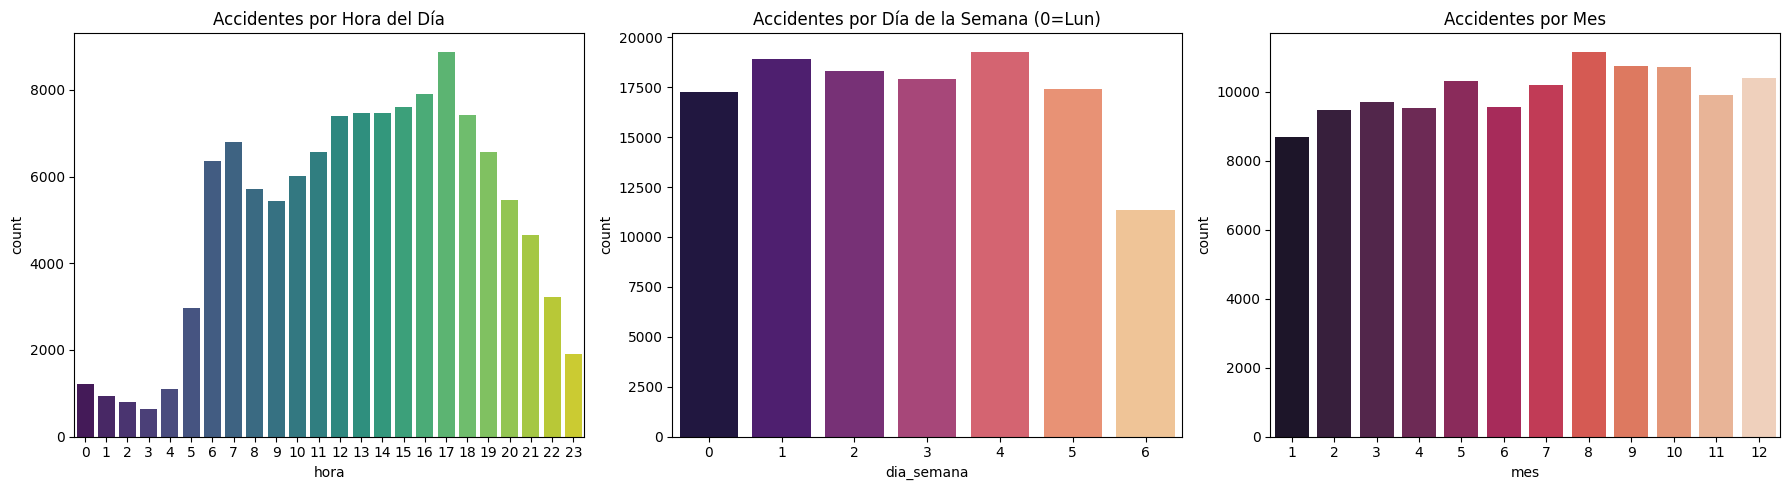

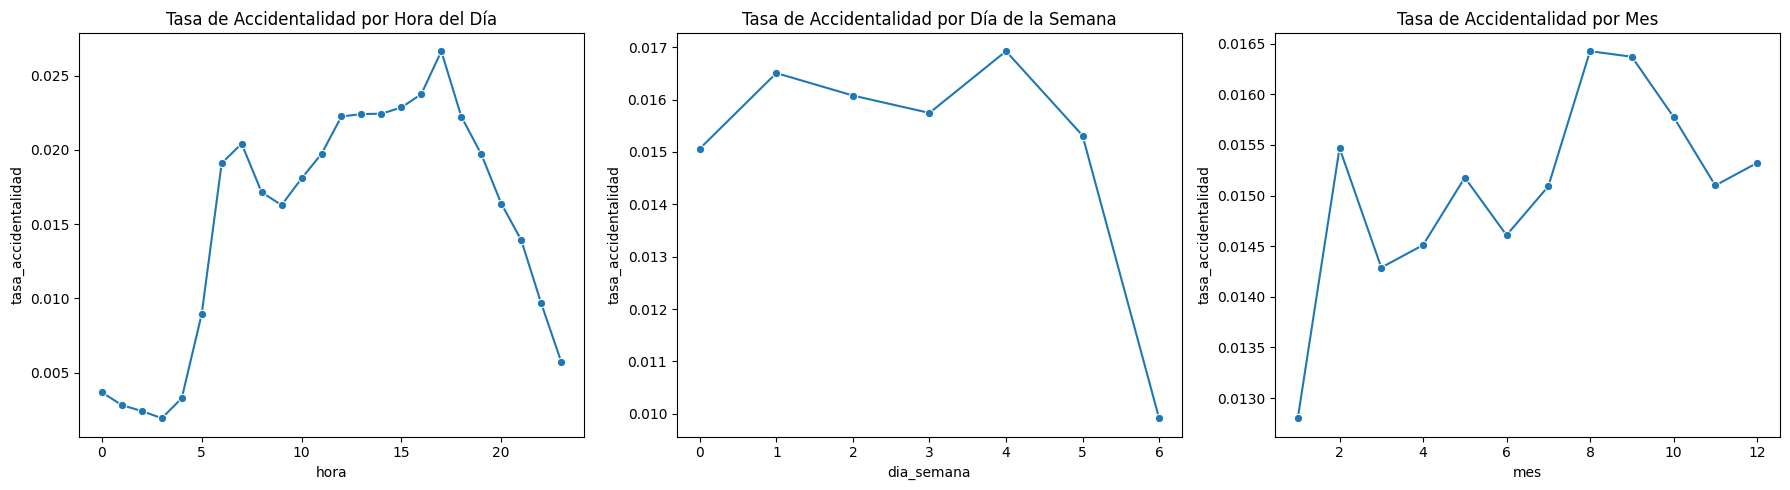

In [44]:
# Distribución temporal de los accidentes, por hora, día y mes

def plot_distribucion_temporal(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Solo nos interesan los registros donde hubo accidente para este análisis descriptivo
    df_acc = df[df['target'] == 1]

    sns.countplot(x='hora', data=df_acc, ax=axes[0], palette='viridis')
    axes[0].set_title('Accidentes por Hora del Día')

    sns.countplot(x='dia_semana', data=df_acc, ax=axes[1], palette='magma')
    axes[1].set_title('Accidentes por Día de la Semana (0=Lun)')

    sns.countplot(x='mes', data=df_acc, ax=axes[2], palette='rocket')
    axes[2].set_title('Accidentes por Mes')

    plt.tight_layout()
    plt.show()

def plot_tasa_temporal(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    tasa_hora = (
        df.groupby('hora')
        .agg(total_observaciones=('target', 'count'), accidentes=('target', 'sum'), tasa_accidentalidad=('target', 'mean'))
        .reset_index()
    )

    tasa_dia = (
        df.groupby('dia_semana')
        .agg(total_observaciones=('target', 'count'), accidentes=('target', 'sum'), tasa_accidentalidad=('target', 'mean'))
        .reset_index()
    )

    tasa_mes = (
        df.groupby('mes')
        .agg(total_observaciones=('target', 'count'), accidentes=('target', 'sum'), tasa_accidentalidad=('target', 'mean'))
        .reset_index()
    )

    sns.lineplot(data=tasa_hora, x='hora', y='tasa_accidentalidad', marker='o', ax=axes[0])
    axes[0].set_title('Tasa de Accidentalidad por Hora del Día')

    sns.lineplot(data=tasa_dia, x='dia_semana', y='tasa_accidentalidad', marker='o', ax=axes[1])
    axes[1].set_title('Tasa de Accidentalidad por Día de la Semana')

    sns.lineplot(data=tasa_mes, x='mes', y='tasa_accidentalidad', marker='o', ax=axes[2])
    axes[2].set_title('Tasa de Accidentalidad por Mes')

    plt.tight_layout()
    plt.show()


plot_distribucion_temporal(df_final)
plot_tasa_temporal(df_final)

Se evidencia un comportamiento interesante en la accidentalidad por hora del día, siendo baja en horas de la madrugada, teniendo su máximo a las 17:00 y bajando a partir de ahí

Podemos ver cómo la accidentalidad es considerablemente menor el domingo comparada con los demás días de la semana

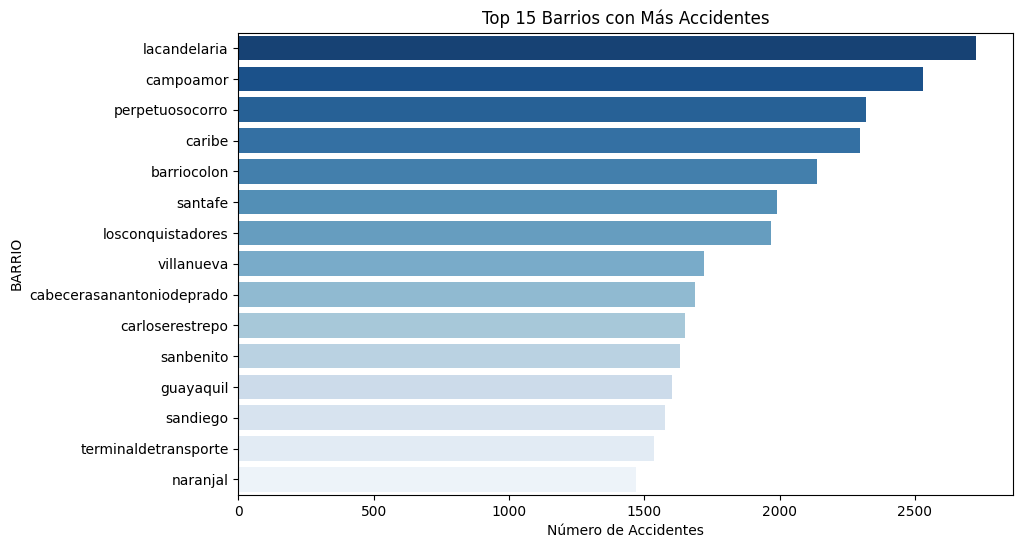

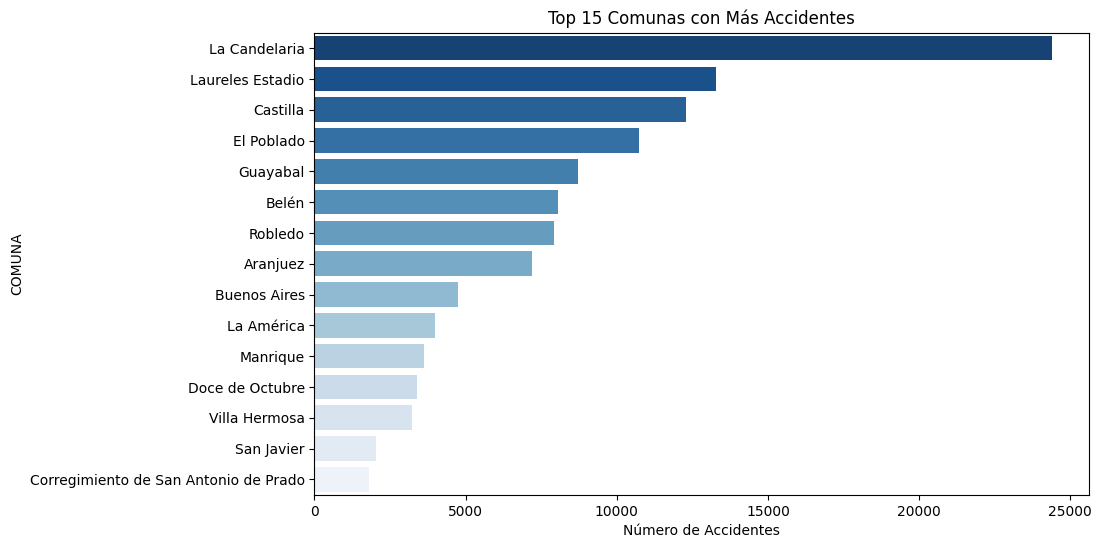

In [45]:
# Distribución espacial de los accidentes

# Usamos la tabla raw_accidentes para determinar la comuna donde ocurrió el accidente
df_barrio_comuna = (
    raw[['BARRIO', 'COMUNA']]
    .dropna()
    .groupby('BARRIO')['COMUNA']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)

df_final = df_final.merge(df_barrio_comuna, on='BARRIO', how='left')


def plot_top_barrios(df, n=15):
    plt.figure(figsize=(10, 6))
    top_barrios = df[df['target'] == 1]['BARRIO'].value_counts().head(n)
    sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='Blues_r')
    plt.title(f'Top {n} Barrios con Más Accidentes')
    plt.xlabel('Número de Accidentes')
    plt.show()

def plot_top_comunas(df, n=15):
    plt.figure(figsize=(10, 6))
    top_comunas = df[df['target'] == 1]['COMUNA'].value_counts().head(n)
    sns.barplot(x=top_comunas.values, y=top_comunas.index, palette='Blues_r')
    plt.title(f'Top {n} Comunas con Más Accidentes')
    plt.xlabel('Número de Accidentes')
    plt.show()


plot_top_barrios(df_final)
plot_top_comunas(df_final)

Se observa cómo el barrio y la comuna de mayor accidentalidad reportada es La Candelaria

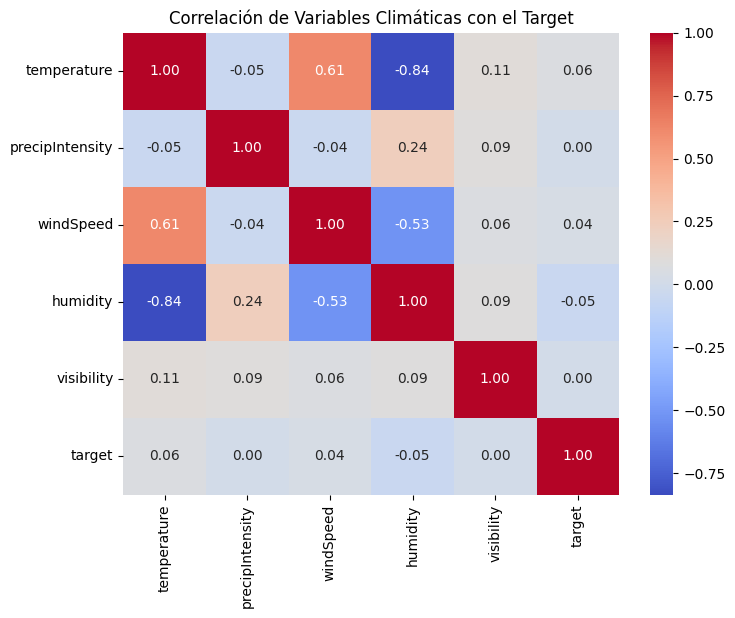

In [46]:
# Caracterización del clima

def analizar_clima_target(df):
    # Seleccionar variables climáticas relevantes
    cols_clima = ['temperature', 'precipIntensity', 'windSpeed', 'humidity', 'visibility', 'target']

    # Matriz de Correlación
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[cols_clima].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlación de Variables Climáticas con el Target')
    plt.show()

analizar_clima_target(df_final)

En la matriz de correlación no se evidencia ninguna correlación fuerte, ya sea positiva o negativa entre alguna variable climática y el target, esto no significa que las variables climáticas no influyan en la accidentalidad, sino que el análisis en la matriz de correlación no es lo suficientemente revelador por varios factores, como que el target es una variable binaria, por lo que es necesario usar otros métodos para capturar la relación

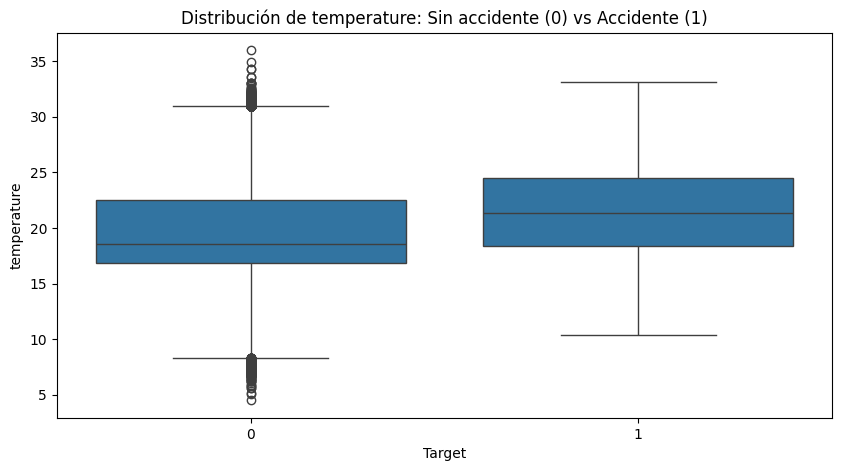

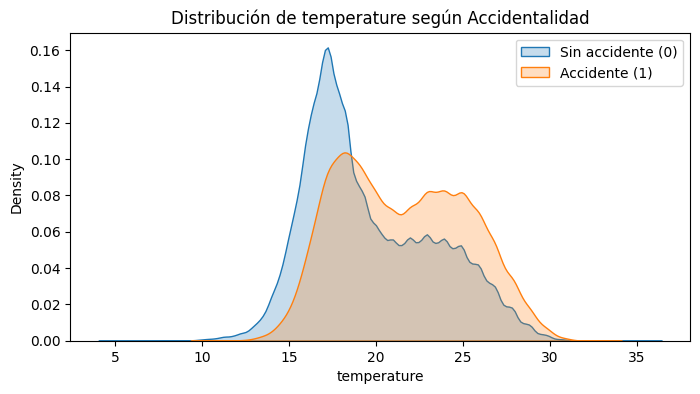

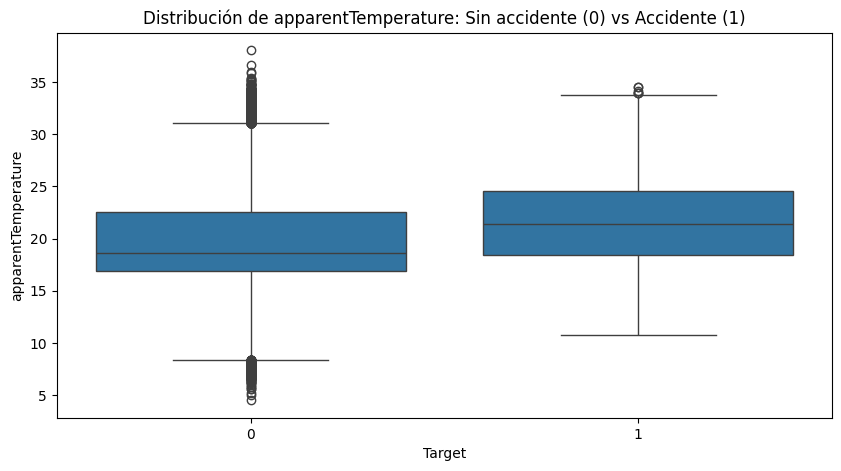

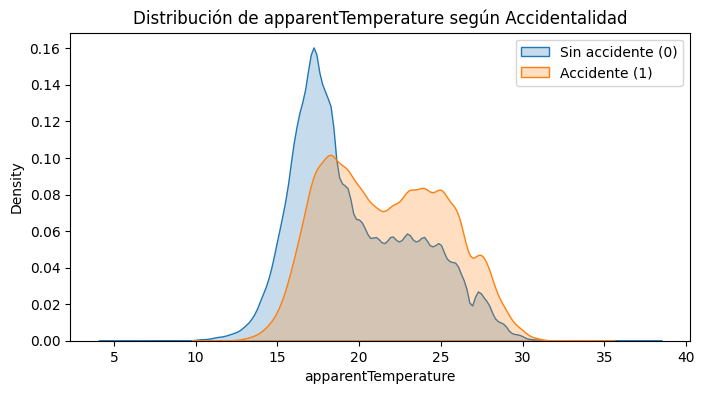

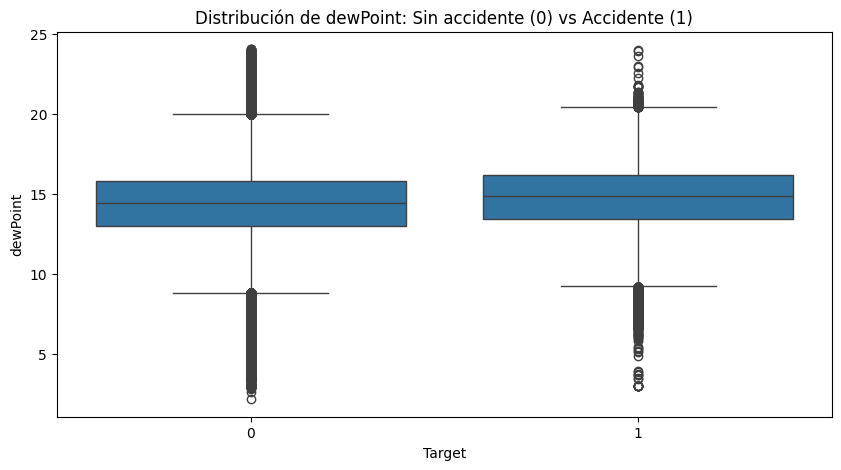

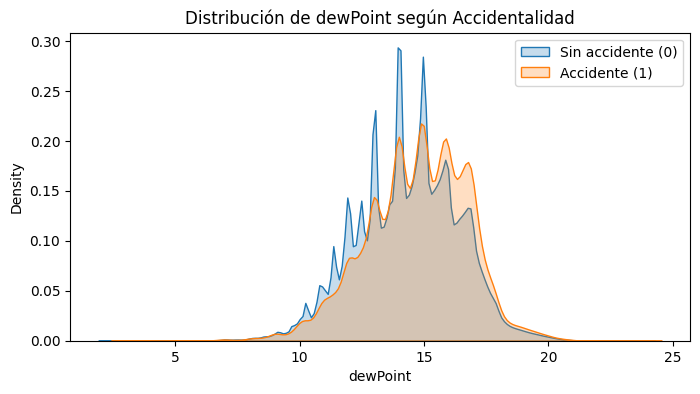

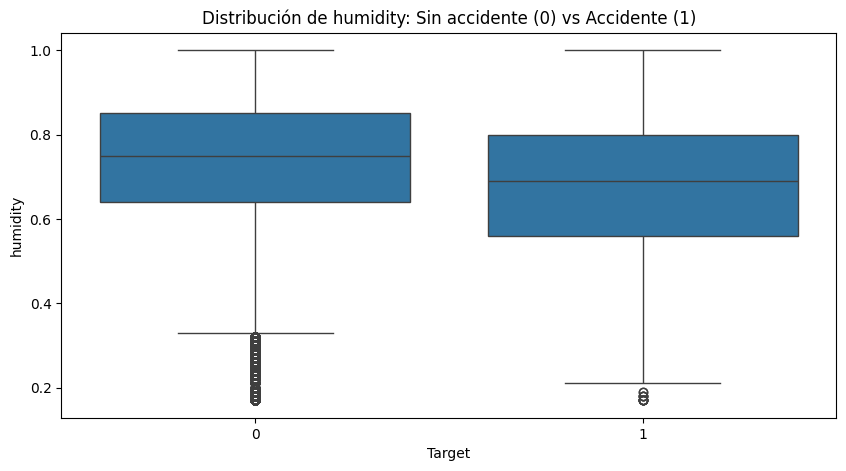

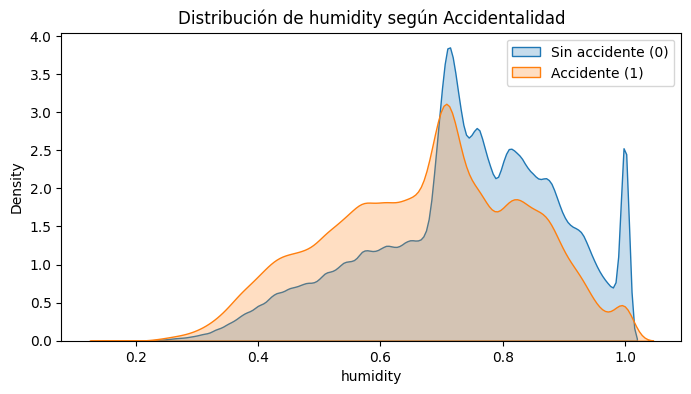

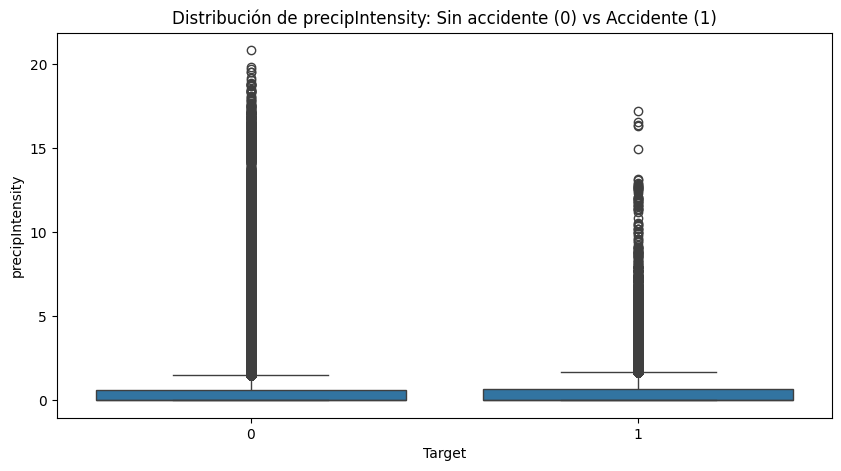

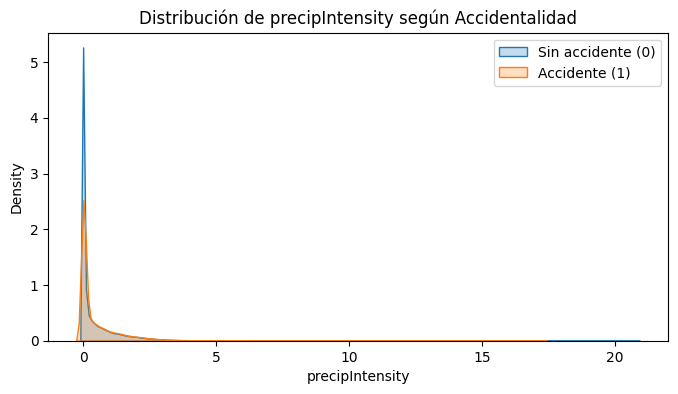

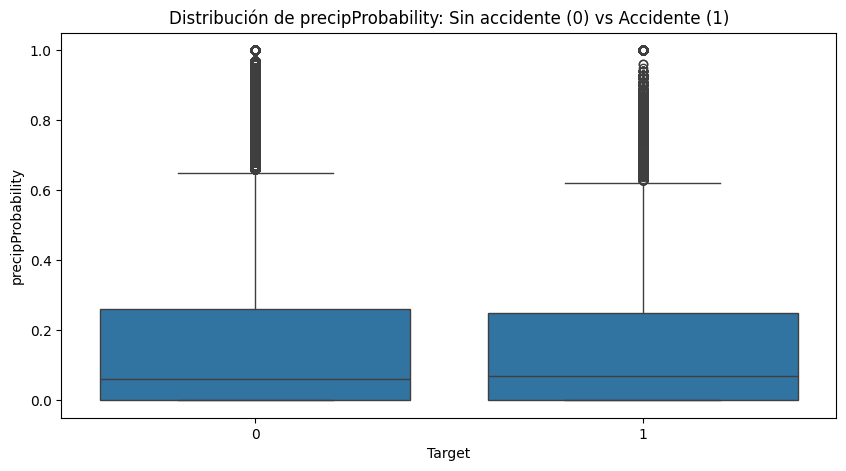

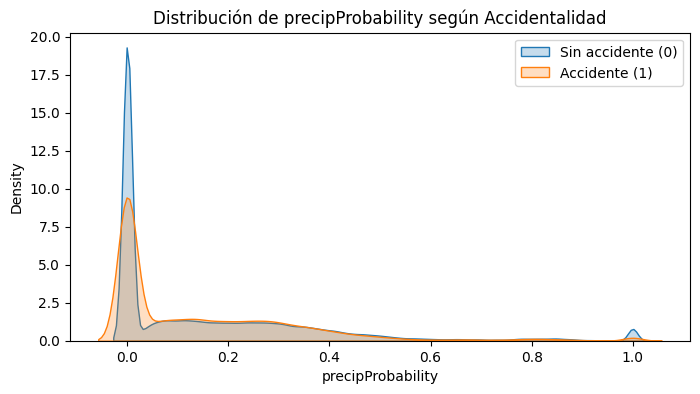

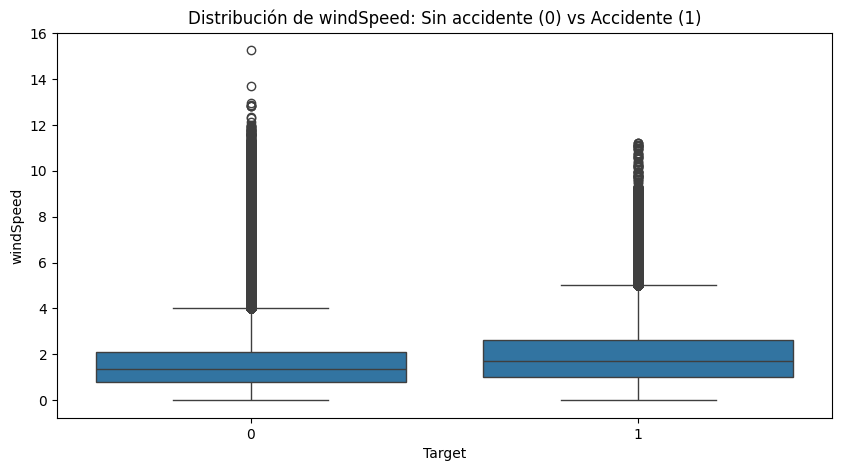

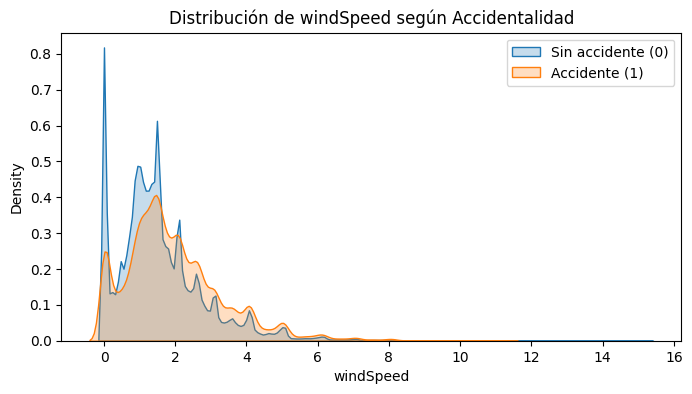

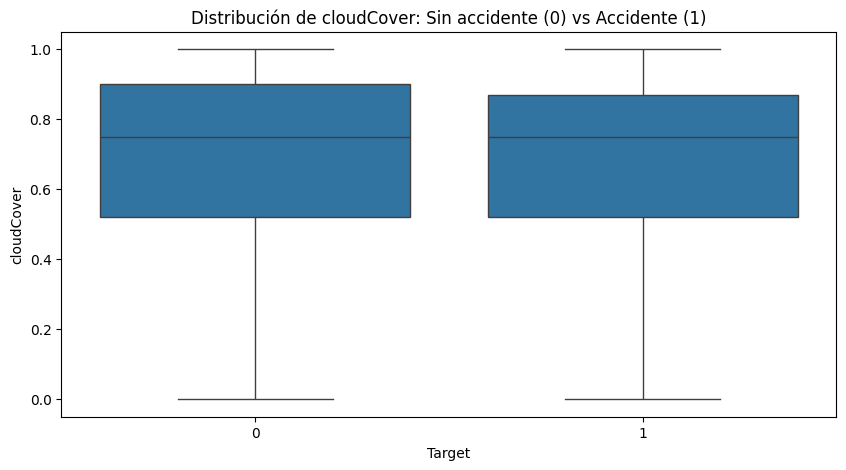

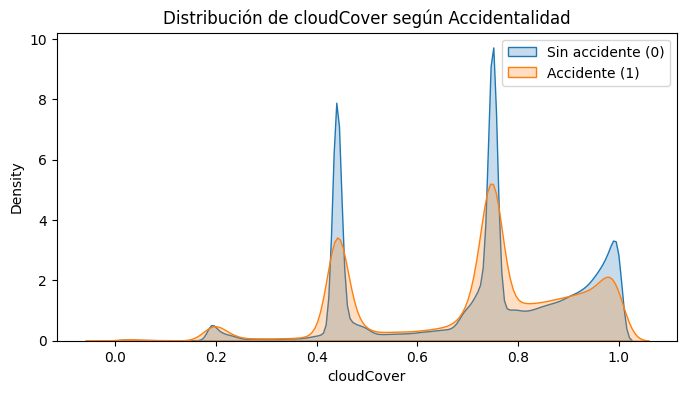

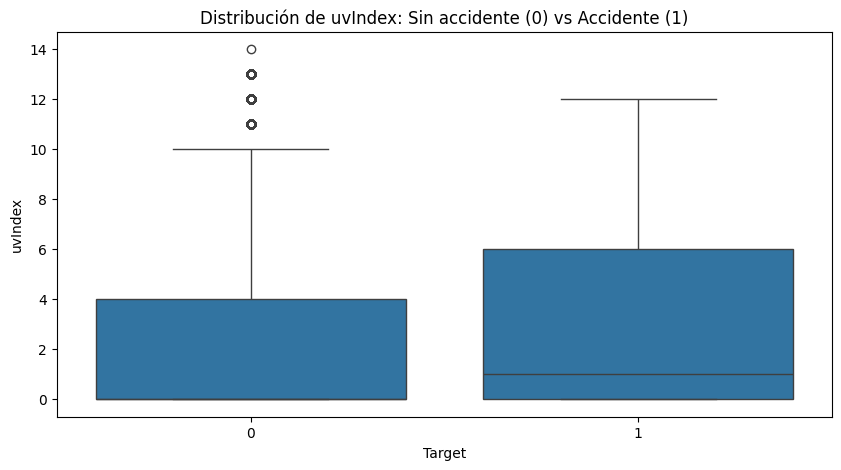

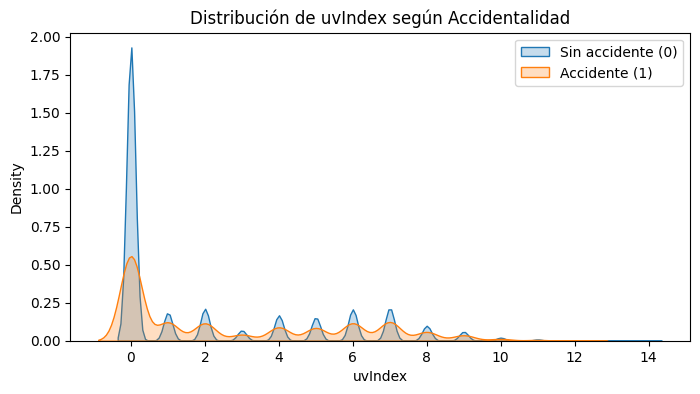

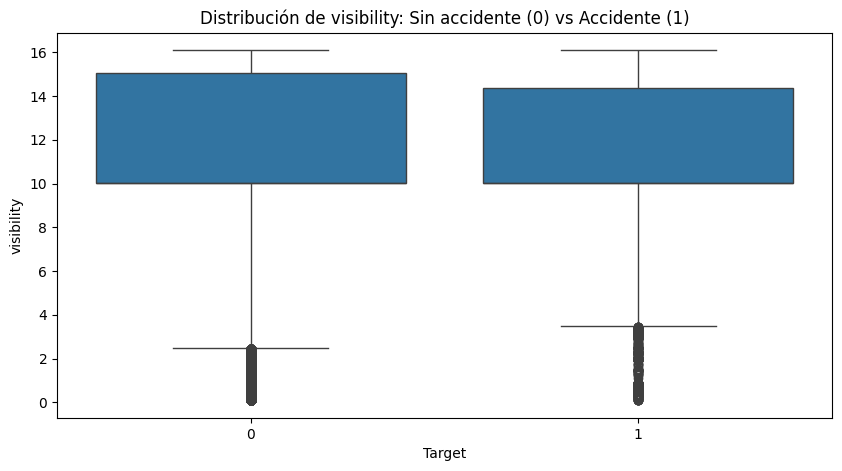

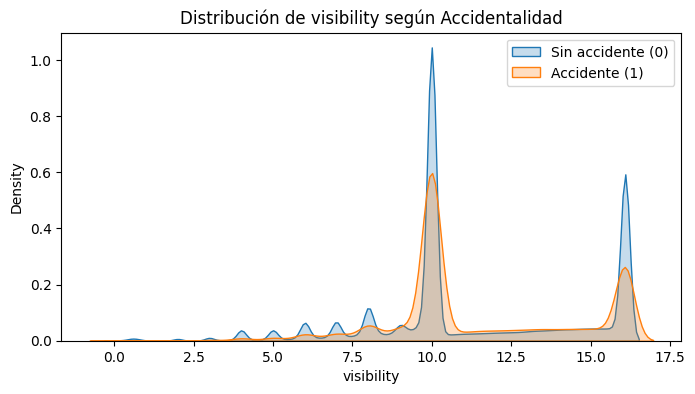

In [47]:
# Observamos las distribuciones de las variables tanto para accidentes como para sin ellos
def plot_boxplot_variable(df, variable):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='target', y=variable, data=df)
    plt.title(f'Distribución de {variable}: Sin accidente (0) vs Accidente (1)')
    plt.xlabel('Target')
    plt.ylabel(variable)
    plt.show()

def plot_comparacion_distribuciones(df, variable):
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df[df['target']==0], x=variable, label='Sin accidente (0)', fill=True)
    sns.kdeplot(data=df[df['target']==1], x=variable, label='Accidente (1)', fill=True)
    plt.title(f'Distribución de {variable} según Accidentalidad')
    plt.legend()
    plt.show()

variables_clima = [
    'temperature', 'apparentTemperature', 'dewPoint',
    'humidity', 'precipIntensity', 'precipProbability',
    'windSpeed', 'cloudCover', 'uvIndex', 'visibility'
]
for variable in variables_clima:
    plot_boxplot_variable(df_final, variable)
    plot_comparacion_distribuciones(df_final, variable)


In [48]:
resumen_clima_target = (
    df_final
    .groupby('target')[variables_clima]
    .agg(['mean', 'median', 'std'])
)

resumen_clima_target

temperature                  apparentTemperature                   \
              mean median       std                mean median       std   
target                                                                     
0        19.624997  18.57  3.746981           19.698304  18.67  3.751562   
1        21.535629  21.34  3.684016           21.615155  21.43  3.685750   

         dewPoint                   humidity  ... windSpeed cloudCover         \
             mean median       std      mean  ...       std       mean median   
target                                        ...                               
0       14.332735  14.41  2.032198  0.735288  ...  1.254486   0.722608   0.75   
1       14.722896  14.89  2.018665  0.673776  ...  1.412568   0.711025   0.75   

                   uvIndex                  visibility                    
             std      mean median       std       mean  median       std  
target                                                                    
0       0.207940  1.992976    0.0  2.865402  11.316265  10.003  3.402731  
1       0.207232  2.781610    1.0  3.064163  11.417221  10.003  3.037097  

[2 rows x 30 columns]

In [49]:
medianas_clima = df_final.groupby('target')[variables_clima].median().T

medianas_clima.columns = ['sin_accidente_0', 'accidente_1']

medianas_clima['diferencia_mediana'] = (
    medianas_clima['accidente_1'] - medianas_clima['sin_accidente_0']
)

medianas_clima = medianas_clima.sort_values(
    'diferencia_mediana',
    ascending=False
)

medianas_clima

,sin_accidente_0,accidente_1,diferencia_mediana
temperature,18.5700,21.3400,2.770
apparentTemperature,18.6700,21.4300,2.760
uvIndex,0.0000,1.0000,1.000
dewPoint,14.4100,14.8900,0.480
windSpeed,1.3600,1.6900,0.330
precipProbability,0.0600,0.0700,0.010
precipIntensity,0.0301,0.0361,0.006
cloudCover,0.7500,0.7500,0.000
visibility,10.0030,10.0030,0.000
humidity,0.7500,0.6900,-0.060


Al comparar las variables climáticas entre registros sin accidente y con accidente, se observa que no existe una separación perfecta entre ambas clases. Las distribuciones presentan un alto grado de solapamiento, lo cual indica que el clima por sí solo no explica completamente la ocurrencia de accidentes.

Sin embargo, algunas variables muestran diferencias sistemáticas. Las variables temperature y apparentTemperature presentan las mayores diferencias de mediana, con valores aproximadamente 2.7 unidades superiores en los registros con accidente. Esto sugiere que las condiciones más cálidas podrían estar asociadas con una mayor accidentalidad observada.

También se identifican diferencias moderadas en uvIndex, dewPoint y windSpeed. En particular, windSpeed presenta una mediana mayor en los registros con accidente, lo que indica una posible señal débil relacionada con el viento. Por otro lado, humidity muestra una mediana menor en los casos con accidente.

Las variables de precipitación, precipIntensity y precipProbability, presentan diferencias pequeñas entre clases y una alta concentración de valores cercanos a cero. Por esta razón, para la fase de ingeniería de características crearemos variables derivadas como llueve y alta_prob_lluvia, que pueden capturar mejor la presencia o ausencia de lluvia.

En conclusión, las variables climáticas no parecen tener una capacidad discriminante fuerte de manera individual, pero sí aportan señales útiles que pueden complementar las variables temporales, espaciales e históricas dentro del modelo predictivo.

# Calidad de Datos

In [50]:
for nombre, df in {
    'accidentes': accidentes,
    'clima': clima,
    'raw': raw
}.items():
    print(f'\n--- {nombre} ---')
    print(df.shape)
    print(df.dtypes)
    print('TW mínimo:', df['TW'].min())
    print('TW máximo:', df['TW'].max())
    print('Nulos en TW:', df['TW'].isna().sum())


--- accidentes ---
(120587, 8)
TW         datetime64[us]
BARRIO                str
Lat               float64
Lon               float64
Dia_sem               str
Mes                 int64
Dia                 int64
Hora                int64
dtype: object
TW mínimo: 2017-01-01 00:00:00
TW máximo: 2019-12-31 23:00:00
Nulos en TW: 0

--- clima ---
(7991780, 15)
TW                     datetime64[us]
BARRIO                            str
summary                           str
icon                              str
precipIntensity               float64
precipProbability             float64
temperature                   float64
apparentTemperature           float64
dewPoint                      float64
humidity                      float64
windSpeed                     float64
windBearing                   float64
cloudCover                    float64
uvIndex                       float64
visibility                    float64
dtype: object
TW mínimo: 2017-01-01 00:00:00
TW máximo: 2019-12-31 23:

In [51]:
for nombre, df in {'accidentes': accidentes, 'clima': clima, 'raw': raw}.items():
    minutos_no_cero = (df['TW'].dt.minute != 0).sum()
    segundos_no_cero = (df['TW'].dt.second != 0).sum()
    print(nombre, minutos_no_cero, segundos_no_cero)

accidentes 0 0
clima 0 0
raw 0 0


Se verificó la estructura general de las tres tablas disponibles. Las tablas accidentes, clima y raw_accidentes cubren el mismo período temporal, desde el 1 de enero de 2017 hasta el 31 de diciembre de 2019. Además, en las tres tablas la columna TW fue cargada correctamente como tipo datetime64, no presenta valores nulos y se encuentra truncada a la hora, ya que no se identificaron registros con minutos o segundos diferentes de cero.

Esto confirma que TW puede utilizarse como llave temporal confiable para unir las tablas a nivel horario. La consistencia del rango temporal entre las tres fuentes también indica que no hay desfases evidentes de cobertura temporal entre accidentes, clima y registros crudos.

In [52]:
def revisar_duplicados_llave(df, nombre):
    duplicados = df.duplicated(subset=['TW', 'BARRIO']).sum()
    print(f'{nombre}: {duplicados} duplicados en la llave TW-BARRIO')

    if duplicados > 0:
        display(
            df[df.duplicated(subset=['TW', 'BARRIO'], keep=False)]
            .sort_values(['BARRIO', 'TW'])
            .head(20)
        )

revisar_duplicados_llave(clima, 'clima')
revisar_duplicados_llave(accidentes, 'accidentes')

clima: 0 duplicados en la llave TW-BARRIO
accidentes: 0 duplicados en la llave TW-BARRIO


La llave compuesta TW-BARRIO es consistente en las dos tablas principales que se van a unir. En clima, cada fila representa una única medición climática para un barrio y una hora. En accidentes, cada fila representa una combinación barrio-hora donde ocurrió al menos un accidente.

Esto es positivo porque permite hacer el merge sin riesgo de duplicar filas artificialmente.

In [53]:
barrios_clima = set(clima['BARRIO'].dropna().unique())
barrios_acc = set(accidentes['BARRIO'].dropna().unique())
barrios_raw = set(raw['BARRIO'].dropna().unique())

print('Barrios en clima:', len(barrios_clima))
print('Barrios en accidentes:', len(barrios_acc))
print('Barrios en raw:', len(barrios_raw))

print('Barrios en accidentes que no están en clima:', len(barrios_acc - barrios_clima), barrios_acc - barrios_clima)
print('Barrios en raw que no están en clima:', len(barrios_raw - barrios_clima), barrios_raw - barrios_clima)

sorted([b for b in clima['BARRIO'].unique() if 'aguas' in b])
sorted([b for b in clima['BARRIO'].unique() if 'astill' in b])
sorted([b for b in clima['BARRIO'].unique() if 'yarum' in b])

Barrios en clima: 319
Barrios en accidentes: 322
Barrios en raw: 322
Barrios en accidentes que no están en clima: 3 {'elastillero', 'suburbanoaguasfrias', 'yarumalito'}
Barrios en raw que no están en clima: 3 {'elastillero', 'suburbanoaguasfrias', 'yarumalito'}


[]

Se identificaron 3 barrios presentes en accidentes y raw_accidentes que no aparecen en clima: yarumalito, suburbanoaguasfrias y elastillero. Dado que la tabla clima define el universo de combinaciones barrio-hora con variables predictoras, estos barrios no pueden incorporarse directamente al dataset supervisado. Se revisó esta diferencia como una inconsistencia de cobertura geográfica. En ausencia de una correspondencia confiable con nombres existentes en clima, estos casos se dejan fuera del universo modelable.

In [54]:
acc_keys = accidentes[['TW', 'BARRIO']].drop_duplicates()
clima_keys = clima[['TW', 'BARRIO']].drop_duplicates()

acc_sin_clima = acc_keys.merge(
    clima_keys,
    on=['TW', 'BARRIO'],
    how='left',
    indicator=True
)

acc_sin_clima = acc_sin_clima[acc_sin_clima['_merge'] == 'left_only']

print('Combinaciones accidente sin registro climático:', acc_sin_clima.shape[0])
display(acc_sin_clima.head())

Combinaciones accidente sin registro climático: 112


,TW,BARRIO,_merge
51964,2018-05-20 05:00:00,elraizal,left_only
51965,2018-05-20 05:00:00,auresno2,left_only
56839,2018-06-21 05:00:00,sanpablo,left_only
57688,2018-06-24 16:00:00,sanmiguel,left_only
57689,2018-06-24 16:00:00,losconquistadores,left_only


Se encontraron 112 combinaciones TW-BARRIO presentes en la tabla accidentes pero ausentes en clima. Esto representa aproximadamente el 0.093 % de los registros positivos de accidentes. Debido a que no existe información climática para esas combinaciones, no se incorporan al dataset final de modelado. Esta decisión evita crear registros artificiales con predictores imputados completamente y tiene un impacto marginal sobre el total de casos positivos.

In [55]:
def resumen_nulos(df, nombre):
    resumen = (
        df.isna().sum()
        .to_frame('nulos')
        .assign(porcentaje=lambda x: 100 * x['nulos'] / len(df))
        .sort_values('porcentaje', ascending=False)
    )

    print(f'\n--- Nulos en {nombre} ---')
    display(resumen[resumen['nulos'] > 0])

resumen_nulos(accidentes, 'accidentes')
resumen_nulos(clima, 'clima')
resumen_nulos(raw, 'raw')
resumen_nulos(df_final, 'df_final')


--- Nulos en accidentes ---


,nulos,porcentaje



--- Nulos en clima ---


,nulos,porcentaje
windBearing,1032513,12.919687
icon,548641,6.865066
summary,548641,6.865066
precipProbability,547401,6.849550
precipIntensity,547401,6.849550
windSpeed,32793,0.410334
cloudCover,7950,0.099477
visibility,4290,0.053680
uvIndex,4280,0.053555
humidity,915,0.011449



--- Nulos en raw ---


,nulos,porcentaje
MES_NOMBRE,82740,66.127460
DISENO,429,0.342865
RADICADO,5,0.003996



--- Nulos en df_final ---


,nulos,porcentaje
windBearing,1032513,12.919687
icon,548641,6.865066
summary,548641,6.865066
precipIntensity,547401,6.849550
precipProbability,547401,6.849550
windSpeed,32793,0.410334
cloudCover,7950,0.099477
visibility,4290,0.053680
uvIndex,4280,0.053555
humidity,915,0.011449


Los valores faltantes se concentran principalmente en variables climáticas y descriptivas. Debido al fuerte desbalance del problema, no se eliminarán filas con nulos, ya que esto podría reducir aún más la cantidad de casos positivos. En su lugar, aplicaremos los tratamientos pertinentes después de realizar la partición temporal de los datos, ajustando los imputadores únicamente con el conjunto de entrenamiento para evitar fuga de información.

Las variables categóricas summary e icon se imputarán con la categoría “desconocido”. Las variables climáticas numéricas con faltantes se imputarán con la mediana calculada sobre el conjunto de entrenamiento, ya que la mediana es robusta frente a valores extremos. Para precipIntensity y precipProbability, además de la imputación, se crearán variables derivadas como llueve y alta_prob_lluvia, dado que la precipitación presenta una distribución muy concentrada cerca de cero.

La variable windBearing se excluirá en la primera versión del modelo porque presenta el mayor porcentaje de faltantes. En raw_accidentes, MES_NOMBRE no se utilizará por ser redundante con Mes, mientras que RADICADO, OBJECTID y variables identificadoras no se usarán como predictores.

In [56]:
df_final[variables_clima].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
temperature,7991170.0,19.653798,3.753267,4.510,13.110,14.780,16.830,18.6100,22.5200,26.5500,28.4900,35.9900
apparentTemperature,7991170.0,19.727199,3.757843,4.510,13.180,14.840,16.890,18.7100,22.6000,26.5800,28.5300,38.0600
dewPoint,7991475.0,14.338617,2.032550,2.160,9.500,10.940,13.000,14.4200,15.7900,17.4400,18.9000,24.0400
humidity,7990865.0,0.734361,0.155438,0.170,0.350,0.440,0.640,0.7400,0.8500,0.9800,1.0000,1.0000
precipIntensity,7444379.0,0.476144,0.891924,0.000,0.000,0.000,0.000,0.0302,0.6058,2.2481,3.9843,20.8236
precipProbability,7444379.0,0.159590,0.219553,0.000,0.000,0.000,0.000,0.0600,0.2600,0.6000,1.0000,1.0000
windSpeed,7958987.0,1.582619,1.257904,0.000,0.000,0.000,0.810,1.3600,2.0900,4.0600,5.9600,15.2600
cloudCover,7983830.0,0.722433,0.207934,0.000,0.190,0.440,0.520,0.7500,0.9000,0.9900,1.0000,1.0000
uvIndex,7987500.0,2.004863,2.870109,0.000,0.000,0.000,0.000,0.0000,4.0000,8.0000,9.0000,14.0000
visibility,7987490.0,11.317787,3.397533,0.099,2.997,6.004,10.003,10.0030,15.0200,16.0930,16.0930,16.0930


El análisis descriptivo de las variables climáticas muestra que, en general, los rangos observados son plausibles y no evidencian valores físicamente imposibles. Las variables humidity, precipProbability y cloudCover se encuentran dentro del rango esperado entre 0 y 1. Las variables temperature, apparentTemperature y dewPoint también presentan valores razonables para el contexto del problema, por lo que no se eliminarán registros por estos campos.

Sin embargo, algunas variables presentan distribuciones asimétricas y valores extremos. En particular, precipIntensity está fuertemente sesgada a la derecha: la mayoría de los registros tienen valores cercanos a cero, pero existen eventos de lluvia intensa con valores considerablemente más altos. De forma similar, windSpeed presenta algunos valores altos frente a su distribución central. Estos valores no se eliminan automáticamente, ya que pueden representar condiciones climáticas reales y potencialmente relevantes para la accidentalidad.

Para evitar que los valores extremos dominen el aprendizaje del modelo, se propone aplicar transformaciones logarítmicas como precipIntensity_log y windSpeed_log después de realizar la imputación correspondiente.

La variable uvIndex presenta una alta concentración en cero, lo cual es esperable por la presencia de horas nocturnas, y valores altos que pueden corresponder a horas de mayor radiación solar. Por su parte, visibility muestra valores concentrados en niveles específicos, posiblemente asociados a la forma de medición o redondeo de la fuente meteorológica. En ambos casos, los valores se consideran válidos y se conservarán para el modelado.

En conclusión, no se identifican valores imposibles que justifiquen eliminar observaciones. El tratamiento se enfocará en imputar los valores faltantes usando únicamente el conjunto de entrenamiento, conservar las variables climáticas relevantes y crear transformaciones o variables derivadas que reduzcan el efecto de distribuciones sesgadas sin perder información potencialmente útil.

#  Unión de tablas e ingeniería de características

Se usa left join tomando clima como tabla base porque clima contiene el universo de combinaciones barrio-hora a modelar. La tabla accidentes contiene únicamente combinaciones donde sí ocurrió al menos un accidente. Por tanto, si una combinación aparece en clima pero no en accidentes, se interpreta como un caso negativo. Esta estrategia permite construir tanto la clase positiva como la negativa.

In [57]:
import holidays

def agregar_variables_temporales(df):
    df = df.copy()

    df['anio'] = df['TW'].dt.year
    df['dia'] = df['TW'].dt.day
    df['dia_anio'] = df['TW'].dt.dayofyear

    # 0 = lunes, 6 = domingo
    df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    return df


def agregar_festivos_colombia(df):
    df = df.copy()

    anios = sorted(df['TW'].dt.year.unique())
    festivos_colombia = holidays.country_holidays('CO', years=anios)

    df['fecha'] = df['TW'].dt.date
    df['es_festivo'] = df['fecha'].isin(festivos_colombia).astype(int)

    return df


df_final = agregar_variables_temporales(df_final)
df_final = agregar_festivos_colombia(df_final)


In [58]:
def agregar_variables_ciclicas(df):
    df = df.copy()

    # Hora del día: ciclo de 24 horas
    df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
    df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

    # Día de semana: ciclo de 7 días
    df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)

    # Día del año: ciclo anual
    df['dia_anio_sin'] = np.sin(2 * np.pi * df['dia_anio'] / 365)
    df['dia_anio_cos'] = np.cos(2 * np.pi * df['dia_anio'] / 365)

    return df


df_final = agregar_variables_ciclicas(df_final)

Las variables cíclicas permiten representar correctamente variables temporales periódicas. Por ejemplo, la hora 23 y la hora 0 son cercanas en el ciclo diario, aunque numéricamente parezcan distantes.

In [59]:
def preparar_clima_pre_split(df):
    df = df.copy()

    # Indicadores de ausencia de datos
    df['precipIntensity_missing'] = df['precipIntensity'].isna().astype(int)
    df['precipProbability_missing'] = df['precipProbability'].isna().astype(int)

    # Se excluye por alto porcentaje de nulos
    df = df.drop(columns=['windBearing'], errors='ignore')

    return df


df_final = preparar_clima_pre_split(df_final)

In [60]:
def agregar_historicos_barrio(df):
    df = df.copy()

    # Ordenar por barrio y tiempo
    df = df.sort_values(['BARRIO', 'TW'])

    # Accidentes acumulados antes del registro actual
    df['acc_hist_barrio'] = (
        df.groupby('BARRIO')['target'].cumsum() - df['target']
    )

    # Número de observaciones previas del barrio
    df['obs_hist_barrio'] = df.groupby('BARRIO').cumcount()

    # Tasa histórica del barrio usando solo observaciones previas
    df['tasa_hist_barrio'] = (
        df['acc_hist_barrio'] / df['obs_hist_barrio'].replace(0, np.nan)
    ).fillna(0)

    return df


df_final = agregar_historicos_barrio(df_final)

In [61]:
def agregar_historicos_barrio_hora(df):
    df = df.copy()

    df = df.sort_values(['BARRIO', 'hora', 'TW'])

    df['acc_hist_barrio_hora'] = (
        df.groupby(['BARRIO', 'hora'])['target'].cumsum() - df['target']
    )

    df['obs_hist_barrio_hora'] = (
        df.groupby(['BARRIO', 'hora']).cumcount()
    )

    df['tasa_hist_barrio_hora'] = (
        df['acc_hist_barrio_hora'] / df['obs_hist_barrio_hora'].replace(0, np.nan)
    ).fillna(0)

    return df


df_final = agregar_historicos_barrio_hora(df_final)

df_final = df_final.sort_values('TW').reset_index(drop=True)

Las variables históricas se calcularon de forma acumulada y excluyendo el registro actual. Para cada combinación barrio-hora, los acumulados y tasas históricas usan únicamente observaciones anteriores en el tiempo dentro del mismo barrio o dentro de la misma combinación barrio-hora. De esta forma, se evita incorporar información futura al momento de predicción y se reduce el riesgo de fuga temporal.

In [62]:
cols_numericas_base = [
    # Climáticas originales
    'precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature',
    'dewPoint', 'humidity', 'windSpeed', 'cloudCover', 'uvIndex', 'visibility',

    # Temporales
    'hora', 'dia_semana', 'mes', 'anio', 'dia',
    'dia_anio', 'es_fin_semana', 'es_festivo',

    # Cíclicas
    'hora_sin', 'hora_cos', 'dia_semana_sin',
    'dia_semana_cos', 'dia_anio_sin', 'dia_anio_cos',

    # Indicadores de faltantes
    'precipIntensity_missing', 'precipProbability_missing',

    # Históricas
    'acc_hist_barrio', 'obs_hist_barrio', 'tasa_hist_barrio',
    'acc_hist_barrio_hora', 'obs_hist_barrio_hora',
    'tasa_hist_barrio_hora'
]

cols_categoricas_ohe = [
    'summary', 'icon', 'COMUNA'
]

col_barrio = 'BARRIO'

cols_numericas_base = [c for c in cols_numericas_base if c in df_final.columns]
cols_categoricas_ohe = [c for c in cols_categoricas_ohe if c in df_final.columns]

columnas_modelo = cols_numericas_base + cols_categoricas_ohe + [col_barrio]

df_modelo = df_final[['TW', 'target'] + columnas_modelo].copy()

Las variables categóricas se codificarán después de la partición temporal para evitar fuga de información. Las variables summary, icon y COMUNA se manejarán con one-hot encoding, ajustado únicamente con el conjunto de entrenamiento y aplicado posteriormente a validación y prueba. Para BARRIO se usará codificación por frecuencia, calculada solo con el conjunto de entrenamiento, debido a su mayor cardinalidad.

In [63]:
df_modelo = df_modelo.sort_values('TW').reset_index(drop=True)

train = df_modelo[df_modelo['TW'] < '2019-01-01'].copy()
valid = df_modelo[df_modelo['TW'] >= '2019-01-01'].copy()

X_train = train[columnas_modelo].copy()
y_train = train['target'].copy()

X_valid = valid[columnas_modelo].copy()
y_valid = valid['target'].copy()

print('Train:', X_train.shape, y_train.mean())
print('Valid:', X_valid.shape, y_valid.mean())

Train: (5381300, 36) 0.014793079739096502
Valid: (2610480, 36) 0.015655741472832583


Se realiza una partición temporal para respetar la naturaleza del problema predictivo. Los registros anteriores a 2019 se usan para entrenamiento y los registros de 2019 para validación. Esta estrategia evita entrenar el modelo con información futura y permite evaluar su desempeño en un período posterior al usado para ajustar el modelo.

La proporción de registros con accidente es de aproximadamente 1.48 % en entrenamiento y 1.57 % en validación. Esto confirma que la partición temporal conserva una distribución de clases similar y mantiene el escenario real de desbalance.

In [64]:
from sklearn.impute import SimpleImputer

imputer_num = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer_num.fit_transform(X_train[cols_numericas_base]),
    columns=cols_numericas_base,
    index=X_train.index
)

X_valid_num = pd.DataFrame(
    imputer_num.transform(X_valid[cols_numericas_base]),
    columns=cols_numericas_base,
    index=X_valid.index
)

Las variables numéricas se imputan con la mediana. El imputador se ajusta únicamente con el conjunto de entrenamiento y luego se aplica al conjunto de validación. Esto evita que la información del período de validación influya en el preprocesamiento.

Se usa la mediana porque es una medida robusta frente a valores extremos, especialmente en variables como precipIntensity y windSpeed, que presentan distribuciones sesgadas.

In [65]:
def crear_derivadas_clima_post_imputacion(X_num):
    X_num = X_num.copy()

    X_num['precipIntensity_log'] = np.log1p(X_num['precipIntensity'])
    X_num['windSpeed_log'] = np.log1p(X_num['windSpeed'])

    X_num['llueve'] = (X_num['precipIntensity'] > 0).astype(int)
    X_num['alta_prob_lluvia'] = (X_num['precipProbability'] >= 0.5).astype(int)

    return X_num


X_train_num = crear_derivadas_clima_post_imputacion(X_train_num)
X_valid_num = crear_derivadas_clima_post_imputacion(X_valid_num)

Después de imputar los valores faltantes, se crean variables derivadas de precipitación y viento. La transformación logarítmica reduce el efecto de valores extremos en variables sesgadas, mientras que las variables binarias llueve y alta_prob_lluvia permiten capturar de forma más interpretable la presencia de lluvia y una probabilidad alta de precipitación.

Estas variables se crean después de la imputación para evitar interpretar valores faltantes como ausencia de lluvia.

In [66]:
X_train_cat = X_train[cols_categoricas_ohe].copy()
X_valid_cat = X_valid[cols_categoricas_ohe].copy()

X_train_cat = X_train_cat.fillna('desconocido').astype(str)
X_valid_cat = X_valid_cat.fillna('desconocido').astype(str)

Las variables categóricas summary, icon y COMUNA se imputan con la categoría "desconocido". Esta decisión permite conservar los registros con información faltante y, al mismo tiempo, representar explícitamente la ausencia de información categórica.

In [67]:
freq_barrio = X_train[col_barrio].value_counts(normalize=True)

X_train_num['BARRIO_freq'] = (
    X_train[col_barrio]
    .map(freq_barrio)
    .fillna(0)
)

X_valid_num['BARRIO_freq'] = (
    X_valid[col_barrio]
    .map(freq_barrio)
    .fillna(0)
)

La variable BARRIO tiene mayor cardinalidad que las demás variables categóricas. Para evitar crear un número elevado de columnas mediante one-hot encoding, se usa codificación por frecuencia.

La frecuencia de cada barrio se calcula únicamente con el conjunto de entrenamiento y luego se aplica al conjunto de validación. Los barrios no observados en entrenamiento reciben frecuencia 0. Esto evita fuga de información desde el período de validación.

In [68]:
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

encoder_ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_train_cat_ohe = encoder_ohe.fit_transform(X_train_cat)
X_valid_cat_ohe = encoder_ohe.transform(X_valid_cat)

Las variables summary, icon y COMUNA se codifican mediante one-hot encoding. El codificador se ajusta únicamente con las categorías observadas en entrenamiento y luego se aplica a validación.

Se usa handle_unknown='ignore' para evitar errores si en validación aparecen categorías no observadas durante el entrenamiento.

In [69]:
X_train_ready = sparse.hstack(
    [
        sparse.csr_matrix(X_train_num.values),
        X_train_cat_ohe
    ],
    format='csr'
)

X_valid_ready = sparse.hstack(
    [
        sparse.csr_matrix(X_valid_num.values),
        X_valid_cat_ohe
    ],
    format='csr'
)

print('X_train_ready:', X_train_ready.shape)
print('X_valid_ready:', X_valid_ready.shape)
print('y_train:', y_train.shape)
print('y_valid:', y_valid.shape)

X_train_ready: (5381300, 90)
X_valid_ready: (2610480, 90)
y_train: (5381300,)
y_valid: (2610480,)


Finalmente, se combinan las variables numéricas procesadas con las variables categóricas codificadas. El resultado son matrices dispersas listas para la fase de modelado.

La matriz final de entrenamiento contiene las variables imputadas, las derivadas climáticas, la codificación por frecuencia de BARRIO y las variables categóricas codificadas mediante one-hot encoding.

Podemos ver que después del preprocesamiento, ambos conjuntos tienen 90 variables finales. Esto confirma que la misma estructura de columnas aprendida en entrenamiento fue aplicada correctamente al conjunto de validación.

In [70]:
feature_names_num = list(X_train_num.columns)
feature_names_cat = list(encoder_ohe.get_feature_names_out(cols_categoricas_ohe))

feature_names = feature_names_num + feature_names_cat

feature_names

['precipIntensity',
 'precipProbability',
 'temperature',
 'apparentTemperature',
 'dewPoint',
 'humidity',
 'windSpeed',
 'cloudCover',
 'uvIndex',
 'visibility',
 'hora',
 'dia_semana',
 'mes',
 'anio',
 'dia',
 'dia_anio',
 'es_fin_semana',
 'es_festivo',
 'hora_sin',
 'hora_cos',
 'dia_semana_sin',
 'dia_semana_cos',
 'dia_anio_sin',
 'dia_anio_cos',
 'precipIntensity_missing',
 'precipProbability_missing',
 'acc_hist_barrio',
 'obs_hist_barrio',
 'tasa_hist_barrio',
 'acc_hist_barrio_hora',
 'obs_hist_barrio_hora',
 'tasa_hist_barrio_hora',
 'precipIntensity_log',
 'windSpeed_log',
 'llueve',
 'alta_prob_lluvia',
 'BARRIO_freq',
 'summary_Clear',
 'summary_Drizzle',
 'summary_Foggy',
 'summary_Heavy Rain',
 'summary_Humid and Mostly Cloudy',
 'summary_Humid and Overcast',
 'summary_Light Rain',
 'summary_Mostly Cloudy',
 'summary_Overcast',
 'summary_Partly Cloudy',
 'summary_Possible Drizzle',
 'summary_Possible Light Rain',
 'summary_Rain',
 'summary_Windy',
 'summary_Windy and 

Se almacenan los nombres de las variables finales para facilitar la interpretación posterior del modelo. Esto será útil para analizar coeficientes, importancias de variables o contribuciones de cada grupo de predictores.

4.4

In [71]:
import gc

# Liberar todo lo que ya no se necesita para 4.4 y 4.5
# Solo se conservan: X_train_ready, X_valid_ready, y_train, y_valid,
# train, valid (para CV temporal en 4.6), feature_names, RANDOM_STATE
variables_a_borrar = [
    'df_modelo', 'df_clima', 'df_accidentes', 'df_raw',
    'accidentes', 'clima', 'raw',
    'X_train', 'X_valid',
    'X_train_num', 'X_valid_num',
    'X_train_cat', 'X_valid_cat',
    'X_train_cat_ohe', 'X_valid_cat_ohe',
    'imputer_num', 'encoder_ohe', 'freq_barrio',
]

for var in variables_a_borrar:
    if var in dir():
        try:
            exec(f'del {var}')
            print(f'   Liberado: {var}')
        except Exception:
            pass

gc.collect()

# Diagnóstico de RAM tras liberar
import psutil
ram = psutil.virtual_memory()
print(f'\nRAM tras limpieza:')
print(f'   Usada: {ram.used / 1024**3:.1f} GB')
print(f'   Disponible: {ram.available / 1024**3:.1f} GB')
print(f'   Porcentaje en uso: {ram.percent:.1f}%')

# Verificar que las variables críticas siguen vivas
criticas = ['X_train_ready', 'X_valid_ready', 'y_train', 'y_valid', 'train', 'valid']
print('\nVariables críticas que deben seguir disponibles:')
for v in criticas:
    print(f'   {v}: {"OK" if v in dir() else "FALTANTE"}')

   Liberado: df_modelo
   Liberado: accidentes
   Liberado: clima
   Liberado: raw
   Liberado: X_train
   Liberado: X_valid
   Liberado: X_train_num
   Liberado: X_valid_num
   Liberado: X_train_cat
   Liberado: X_valid_cat
   Liberado: X_train_cat_ohe
   Liberado: X_valid_cat_ohe
   Liberado: imputer_num
   Liberado: encoder_ohe
   Liberado: freq_barrio

RAM tras limpieza:
   Usada: 13.7 GB
   Disponible: 17.7 GB
   Porcentaje en uso: 43.6%

Variables críticas que deben seguir disponibles:
   X_train_ready: OK
   X_valid_ready: OK
   y_train: OK
   y_valid: OK
   train: OK
   valid: OK


# 4.4 Modelo no sesgado

En esta sección se construye el flujo de modelado bajo dos condiciones que dominan el problema: clases fuertemente desbalanceadas (tasa positiva cercana al 1.5 %) y un volumen elevado de observaciones (más de cinco millones de filas en entrenamiento). El procedimiento se organiza en tres etapas: un baseline ingenuo que demuestra por qué la accuracy no es la métrica adecuada, la comparación de dos estrategias de balanceo y la comparación de tres familias de modelos con ajuste de hiperparámetros mediante validación cruzada temporal.

Todo el ajuste de hiperparámetros se realiza sobre el conjunto de entrenamiento undersampleado a una proporción 5:1, estrategia que en la etapa anterior demostró ser la más eficiente y con mejor desempeño en validación. El conjunto de validación temporal (registros del 2019) se reserva exclusivamente para la evaluación final y no participa en ninguna decisión de modelado.

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, classification_report
)
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from scipy import sparse
import time
import gc
import warnings
warnings.filterwarnings('ignore')


def estimar_tamanio_sparse(matriz):
    """Devuelve el tamaño en MB de una matriz sparse sin materializarla."""
    return (matriz.data.nbytes + matriz.indices.nbytes + matriz.indptr.nbytes) / 1024 / 1024


print('Diagnóstico de memoria y composición del dataset')
print(f'   X_train_ready: {estimar_tamanio_sparse(X_train_ready):.1f} MB (sparse)')
print(f'   X_valid_ready: {estimar_tamanio_sparse(X_valid_ready):.1f} MB (sparse)')
print(f'   y_train: {y_train.values.nbytes / 1024 / 1024:.1f} MB')
print(f'   y_valid: {y_valid.values.nbytes / 1024 / 1024:.1f} MB')

print('\nComposición del dataset')
print(f'   Tasa positiva train: {y_train.mean():.4%}')
print(f'   Tasa positiva valid: {y_valid.mean():.4%}')
print(f'   Filas train: {X_train_ready.shape[0]:,}')
print(f'   Filas valid: {X_valid_ready.shape[0]:,}')
print(f'   Features:    {X_train_ready.shape[1]:,}')

Diagnóstico de memoria y composición del dataset
   X_train_ready: 1914.5 MB (sparse)
   X_valid_ready: 1026.3 MB (sparse)
   y_train: 41.1 MB
   y_valid: 19.9 MB

Composición del dataset
   Tasa positiva train: 1.4793%
   Tasa positiva valid: 1.5656%
   Filas train: 5,381,300
   Filas valid: 2,610,480
   Features:    90


## Baseline ingenuo

Se construyen dos baselines de referencia sin capacidad predictiva real. El primero predice siempre la clase mayoritaria (clase 0, sin accidente). El segundo predice de forma aleatoria respetando la proporción observada de clases. Ambos sirven como piso mínimo: cualquier modelo serio debe superarlos en métricas distintas de la accuracy, ya que la prevalencia de positivos (1.57 %) permite alcanzar una accuracy trivial superior al 98 % sin aprender nada.

In [73]:
# Baseline 1: predecir siempre la clase mayoritaria
dummy_majority = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_majority.fit(X_train_ready, y_train)
y_pred_dummy_maj = dummy_majority.predict(X_valid_ready)

# Baseline 2: predicción aleatoria estratificada por la proporción observada
dummy_strat = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_strat.fit(X_train_ready, y_train)
y_pred_dummy_strat = dummy_strat.predict(X_valid_ready)
y_proba_dummy_strat = dummy_strat.predict_proba(X_valid_ready)[:, 1]

print('Baseline 1: clase mayoritaria siempre')
print(f'   Accuracy : {accuracy_score(y_valid, y_pred_dummy_maj):.6f}')
print(f'   Precision: {precision_score(y_valid, y_pred_dummy_maj, zero_division=0):.6f}')
print(f'   Recall   : {recall_score(y_valid, y_pred_dummy_maj, zero_division=0):.6f}')
print(f'   F1       : {f1_score(y_valid, y_pred_dummy_maj, zero_division=0):.6f}')

print('\nBaseline 2: predicción aleatoria estratificada')
print(f'   Accuracy : {accuracy_score(y_valid, y_pred_dummy_strat):.6f}')
print(f'   Precision: {precision_score(y_valid, y_pred_dummy_strat, zero_division=0):.6f}')
print(f'   Recall   : {recall_score(y_valid, y_pred_dummy_strat, zero_division=0):.6f}')
print(f'   F1       : {f1_score(y_valid, y_pred_dummy_strat, zero_division=0):.6f}')
print(f'   ROC-AUC  : {roc_auc_score(y_valid, y_proba_dummy_strat):.6f}')
print(f'   PR-AUC   : {average_precision_score(y_valid, y_proba_dummy_strat):.6f}')

print('\nLectura del resultado')
print(f'   Tasa real de positivos en validación: {y_valid.mean():.4%}')
print(f'   Accuracy trivial alcanzable sin modelo: {1 - y_valid.mean():.4%}')
print('   Conclusión: la accuracy es engañosa bajo desbalance extremo. Las métricas')
print('   adecuadas para este problema son PR-AUC (principal), ROC-AUC (complemento)')
print('   y, en el umbral final, precision, recall y F1.')

del dummy_majority, dummy_strat, y_pred_dummy_maj, y_pred_dummy_strat, y_proba_dummy_strat
gc.collect()

Baseline 1: clase mayoritaria siempre
   Accuracy : 0.984344
   Precision: 0.000000
   Recall   : 0.000000
   F1       : 0.000000

Baseline 2: predicción aleatoria estratificada
   Accuracy : 0.970058
   Precision: 0.015964
   Recall   : 0.015048
   F1       : 0.015493
   ROC-AUC  : 0.500148
   PR-AUC   : 0.015660

Lectura del resultado
   Tasa real de positivos en validación: 1.5656%
   Accuracy trivial alcanzable sin modelo: 98.4344%
   Conclusión: la accuracy es engañosa bajo desbalance extremo. Las métricas
   adecuadas para este problema son PR-AUC (principal), ROC-AUC (complemento)
   y, en el umbral final, precision, recall y F1.


36296

## Estrategias de balanceo

Se comparan dos estrategias prácticas y reproducibles bajo este tamaño de datos. La primera es el uso de pesos de clase (`class_weight='balanced'`) sobre el conjunto de entrenamiento completo: el modelo penaliza más los errores sobre la clase minoritaria sin modificar los datos. La segunda es el undersampling aleatorio de la clase mayoritaria a una proporción de 5:1, que conserva todos los positivos y reduce los negativos de aproximadamente 5.3 millones a 398 mil, manteniendo la representatividad temporal al ordenar por la marca temporal antes del muestreo.

No se utiliza SMOTE ni otras técnicas de sobremuestreo sintético por dos razones técnicas: con cinco millones de filas, generar sintéticos amplificaría el costo en memoria sin un beneficio claro frente al undersampling; adicionalmente, la interpolación de variables cíclicas y categóricas codificadas no produce instancias realistas.

La comparación se realiza con regresión logística como modelo de prueba, evaluando con PR-AUC y ROC-AUC sobre el conjunto de validación temporal.

In [74]:
def undersample_indices(y, ratio_neg_pos=5, random_state=RANDOM_STATE):
    """Devuelve índices ordenados para undersampling aleatorio de la clase mayoritaria."""
    rng = np.random.RandomState(random_state)
    y_arr = np.asarray(y)
    idx_pos = np.where(y_arr == 1)[0]
    idx_neg = np.where(y_arr == 0)[0]

    n_neg_target = min(len(idx_neg), int(len(idx_pos) * ratio_neg_pos))
    idx_neg_sample = rng.choice(idx_neg, size=n_neg_target, replace=False)

    return np.sort(np.concatenate([idx_pos, idx_neg_sample]))


print('Estrategia 1: class_weight=balanced sobre el train completo')
t0 = time.time()
logreg_cw = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',
    max_iter=200,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
logreg_cw.fit(X_train_ready, y_train)
t_cw = time.time() - t0
proba_cw = logreg_cw.predict_proba(X_valid_ready)[:, 1]
roc_cw = roc_auc_score(y_valid, proba_cw)
pr_cw  = average_precision_score(y_valid, proba_cw)
print(f'   Tamaño train: {X_train_ready.shape[0]:,}')
print(f'   Tiempo entrenamiento: {t_cw:.1f}s')
print(f'   ROC-AUC: {roc_cw:.4f}')
print(f'   PR-AUC : {pr_cw:.4f}')

del logreg_cw, proba_cw
gc.collect()

print('\nEstrategia 2: undersampling 5:1 sobre el train')
idx_us = undersample_indices(y_train.values, ratio_neg_pos=5)
X_train_us = X_train_ready[idx_us]
y_train_us = y_train.values[idx_us]

print(f'   Tamaño tras undersampling: {X_train_us.shape[0]:,} '
      f'(positivos: {int(y_train_us.sum()):,}, '
      f'tasa positiva: {y_train_us.mean():.4f})')

t0 = time.time()
logreg_us = LogisticRegression(
    solver='lbfgs',
    max_iter=200,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
logreg_us.fit(X_train_us, y_train_us)
t_us = time.time() - t0
proba_us = logreg_us.predict_proba(X_valid_ready)[:, 1]
roc_us = roc_auc_score(y_valid, proba_us)
pr_us  = average_precision_score(y_valid, proba_us)
print(f'   Tiempo entrenamiento: {t_us:.1f}s')
print(f'   ROC-AUC: {roc_us:.4f}')
print(f'   PR-AUC : {pr_us:.4f}')

del logreg_us, proba_us
gc.collect()

comparacion_balanceo = pd.DataFrame({
    'estrategia':     ['class_weight=balanced', 'undersampling_5_a_1'],
    'n_train':        [X_train_ready.shape[0], X_train_us.shape[0]],
    'tasa_pos_train': [y_train.mean(), y_train_us.mean()],
    'tiempo_seg':     [t_cw, t_us],
    'roc_auc_valid':  [roc_cw, roc_us],
    'pr_auc_valid':   [pr_cw, pr_us],
})
print('\nTabla comparativa de estrategias de balanceo')
comparacion_balanceo

Estrategia 1: class_weight=balanced sobre el train completo
   Tamaño train: 5,381,300
   Tiempo entrenamiento: 105.4s
   ROC-AUC: 0.7958
   PR-AUC : 0.0734

Estrategia 2: undersampling 5:1 sobre el train
   Tamaño tras undersampling: 477,636 (positivos: 79,606, tasa positiva: 0.1667)
   Tiempo entrenamiento: 11.2s
   ROC-AUC: 0.7920
   PR-AUC : 0.0731

Tabla comparativa de estrategias de balanceo


,estrategia,n_train,tasa_pos_train,tiempo_seg,roc_auc_valid,pr_auc_valid
0,class_weight=balanced,5381300,0.014793,105.399876,0.795812,0.073443
1,undersampling_5_a_1,477636,0.166667,11.151582,0.791970,0.073092


## Comparación de tres familias de modelos

Se comparan tres familias representativas: regresión logística, random forest y gradient boosting (en su implementación `HistGradientBoostingClassifier`, que escala bien por su uso de histogramas y soporta de forma nativa la ponderación de clases). El ajuste de hiperparámetros se realiza con validación cruzada temporal mediante `TimeSeriesSplit` sobre el conjunto de entrenamiento undersampleado, lo cual preserva el orden cronológico y elimina la fuga de información futura.

El criterio de selección dentro de la validación cruzada es el PR-AUC, métrica apropiada bajo desbalance fuerte porque resume el comportamiento del clasificador en la región de interés operativa (alta precisión sobre la clase positiva). El conjunto de validación temporal completo se utiliza únicamente para la evaluación final del mejor candidato de cada familia, una vez reentrenado sobre todo el train undersampleado.

Para `HistGradientBoostingClassifier` se materializan a denso únicamente el conjunto de entrenamiento undersampleado y el conjunto de validación, una sola vez. La conversión es manejable: 478 mil filas y 2.6 millones de filas respectivamente, con 90 columnas en float32.

In [75]:
# Materialización a denso (una sola vez) para HistGradientBoosting
print('Convirtiendo matrices a denso para HistGradientBoosting (una sola vez)')
X_train_us_dense = X_train_us.toarray().astype(np.float32)
X_valid_dense    = X_valid_ready.toarray().astype(np.float32)
print(f'   X_train_us_dense: {X_train_us_dense.nbytes / 1024 / 1024:.1f} MB')
print(f'   X_valid_dense:    {X_valid_dense.nbytes / 1024 / 1024:.1f} MB')
gc.collect()

Convirtiendo matrices a denso para HistGradientBoosting (una sola vez)
   X_train_us_dense: 164.0 MB
   X_valid_dense:    896.2 MB


0

In [76]:
tscv = TimeSeriesSplit(n_splits=3)


def evaluar_grid_cv_sparse(estimator_factory, param_grid, X, y, cv):
    """Validación cruzada temporal para estimadores compatibles con sparse."""
    resultados = []
    for params in ParameterGrid(param_grid):
        pr_scores, roc_scores, tiempos = [], [], []
        for idx_tr, idx_val in cv.split(X):
            t0 = time.time()
            model = estimator_factory(params)
            model.fit(X[idx_tr], y[idx_tr])
            proba = model.predict_proba(X[idx_val])[:, 1]
            tiempos.append(time.time() - t0)
            pr_scores.append(average_precision_score(y[idx_val], proba))
            roc_scores.append(roc_auc_score(y[idx_val], proba))
        resultados.append({**params,
                           'pr_auc_mean':  np.mean(pr_scores),
                           'pr_auc_std':   np.std(pr_scores),
                           'roc_auc_mean': np.mean(roc_scores),
                           'roc_auc_std':  np.std(roc_scores),
                           'tiempo_fold_seg': np.mean(tiempos)})
    return pd.DataFrame(resultados).sort_values('pr_auc_mean', ascending=False).reset_index(drop=True)


def evaluar_grid_cv_dense(estimator_factory, param_grid, X, y, cv):
    """Validación cruzada temporal para estimadores que requieren denso (HistGB)."""
    resultados = []
    for params in ParameterGrid(param_grid):
        pr_scores, roc_scores, tiempos = [], [], []
        for idx_tr, idx_val in cv.split(X):
            t0 = time.time()
            model = estimator_factory(params)
            model.fit(X[idx_tr], y[idx_tr])
            proba = model.predict_proba(X[idx_val])[:, 1]
            tiempos.append(time.time() - t0)
            pr_scores.append(average_precision_score(y[idx_val], proba))
            roc_scores.append(roc_auc_score(y[idx_val], proba))
        resultados.append({**params,
                           'pr_auc_mean':  np.mean(pr_scores),
                           'pr_auc_std':   np.std(pr_scores),
                           'roc_auc_mean': np.mean(roc_scores),
                           'roc_auc_std':  np.std(roc_scores),
                           'tiempo_fold_seg': np.mean(tiempos)})
    return pd.DataFrame(resultados).sort_values('pr_auc_mean', ascending=False).reset_index(drop=True)

In [77]:
# Familia 1: Regresión logística sobre el train undersampleado
def factory_logreg(params):
    return LogisticRegression(
        solver='lbfgs',
        max_iter=300,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        **params
    )

grid_logreg = {
    'C':       [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
}

t0 = time.time()
res_logreg = evaluar_grid_cv_sparse(factory_logreg, grid_logreg, X_train_us, y_train_us, tscv)
print(f'Logística — ajuste completado en {time.time() - t0:.1f}s')
res_logreg

Logística — ajuste completado en 101.5s


,C,penalty,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,tiempo_fold_seg
0,0.10,l2,0.459868,0.010465,0.801816,0.003956,8.420336
1,1.00,l2,0.459105,0.011780,0.802414,0.004641,8.323699
2,10.00,l2,0.456757,0.009855,0.800471,0.003626,8.281959
3,0.01,l2,0.455238,0.008306,0.800667,0.002129,8.509379


In [79]:
# Familia 2: Random Forest sobre el train undersampleado

# Evitar conflicto entre joblib (paralelismo de árboles) y BLAS multi-hilo
# dentro de cada worker. Recomendación oficial de joblib para evitar
# over-subscription y deadlocks bajo presión de memoria.
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['BLIS_NUM_THREADS']     = '1'

from sklearn.model_selection import ParameterGrid


def factory_rf(params):
    return RandomForestClassifier(
        n_jobs=3,                      # 3 workers; deja 1 nucleo libre para el kernel
        random_state=RANDOM_STATE,
        **params
    )


grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 15],
    'min_samples_leaf': [50, 200],
}

combinaciones = list(ParameterGrid(grid_rf))
n_fits_total = len(combinaciones) * tscv.n_splits
print(f'Random Forest: {len(combinaciones)} combinaciones x {tscv.n_splits} folds '
      f'= {n_fits_total} fits')

resultados_rf = []
t_global = time.time()

for i, params in enumerate(combinaciones, 1):
    t_combo = time.time()
    pr_scores, roc_scores, tiempos = [], [], []
    for fold, (idx_tr, idx_val) in enumerate(tscv.split(X_train_us), 1):
        t_fold = time.time()
        model = factory_rf(params)
        model.fit(X_train_us[idx_tr], y_train_us[idx_tr])
        proba = model.predict_proba(X_train_us[idx_val])[:, 1]
        tiempos.append(time.time() - t_fold)
        pr_scores.append(average_precision_score(y_train_us[idx_val], proba))
        roc_scores.append(roc_auc_score(y_train_us[idx_val], proba))
        del model, proba
        gc.collect()
        print(f'   [{i}/{len(combinaciones)}] {params} '
              f'fold {fold}/{tscv.n_splits} -> {tiempos[-1]:.0f}s')
    resultados_rf.append({**params,
                          'pr_auc_mean':     np.mean(pr_scores),
                          'pr_auc_std':      np.std(pr_scores),
                          'roc_auc_mean':    np.mean(roc_scores),
                          'roc_auc_std':     np.std(roc_scores),
                          'tiempo_fold_seg': np.mean(tiempos)})
    print(f'   [{i}/{len(combinaciones)}] COMPLETADA en {time.time() - t_combo:.0f}s '
          f'| pr_auc_mean={np.mean(pr_scores):.4f}')

res_rf = (pd.DataFrame(resultados_rf)
            .sort_values('pr_auc_mean', ascending=False)
            .reset_index(drop=True))
print(f'\nRandom Forest — ajuste completado en {time.time() - t_global:.1f}s')
res_rf

Random Forest: 8 combinaciones x 3 folds = 24 fits
   [1/8] {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 100} fold 1/3 -> 12s
   [1/8] {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 100} fold 2/3 -> 26s
   [1/8] {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 100} fold 3/3 -> 43s
   [1/8] COMPLETADA en 82s | pr_auc_mean=0.4833
   [2/8] {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 200} fold 1/3 -> 23s
   [2/8] {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 200} fold 2/3 -> 54s
   [2/8] {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 200} fold 3/3 -> 86s
   [2/8] COMPLETADA en 164s | pr_auc_mean=0.4838
   [3/8] {'max_depth': 10, 'min_samples_leaf': 200, 'n_estimators': 100} fold 1/3 -> 10s
   [3/8] {'max_depth': 10, 'min_samples_leaf': 200, 'n_estimators': 100} fold 2/3 -> 24s
   [3/8] {'max_depth': 10, 'min_samples_leaf': 200, 'n_estimators': 100} fold 3/3 -> 40s
   [3/8] COMPLETADA en 74s | pr_auc_mean=0.4814
   [4/8] 

,max_depth,min_samples_leaf,n_estimators,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,tiempo_fold_seg
0,15,50,200,0.484443,0.011671,0.820797,0.003662,115.656308
1,15,50,100,0.484216,0.011294,0.820631,0.003509,57.631268
2,10,50,200,0.483804,0.012021,0.819962,0.003762,54.333920
3,10,50,100,0.483303,0.011594,0.819778,0.003564,27.118133
4,10,200,200,0.481392,0.012013,0.819326,0.003660,48.698716
5,10,200,100,0.481379,0.012168,0.819287,0.003678,24.557140
6,15,200,200,0.481376,0.012035,0.819799,0.003517,82.474321
7,15,200,100,0.480996,0.011979,0.819748,0.003419,41.503441


In [80]:
# Familia 3: HistGradientBoosting sobre el train undersampleado (denso)
def factory_hgb(params):
    return HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        early_stopping=False,
        **params
    )

grid_hgb = {
    'learning_rate':     [0.05, 0.1],
    'max_iter':          [200, 400],
    'max_depth':         [None, 8],
    'l2_regularization': [0.0, 1.0],
}

t0 = time.time()
res_hgb = evaluar_grid_cv_dense(factory_hgb, grid_hgb, X_train_us_dense, y_train_us, tscv)
print(f'HistGradientBoosting — ajuste completado en {time.time() - t0:.1f}s')
res_hgb

HistGradientBoosting — ajuste completado en 409.8s


,l2_regularization,learning_rate,max_depth,max_iter,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,tiempo_fold_seg
0,1.0,0.05,8.0,200,0.487538,0.012161,0.822723,0.003527,6.624024
1,0.0,0.05,NaN,200,0.487423,0.012546,0.822529,0.003808,7.044214
2,1.0,0.05,NaN,200,0.487125,0.012848,0.822808,0.003577,6.711583
3,0.0,0.05,8.0,200,0.486623,0.012695,0.822312,0.003700,6.822450
4,1.0,0.05,NaN,400,0.481598,0.011638,0.821170,0.003507,11.455789
5,0.0,0.05,NaN,400,0.481427,0.011646,0.820722,0.003507,10.882202
6,1.0,0.05,8.0,400,0.480726,0.010814,0.820475,0.003409,11.684927
7,1.0,0.10,NaN,200,0.479913,0.009742,0.820444,0.002804,5.717570
8,0.0,0.05,8.0,400,0.478911,0.011124,0.819196,0.004149,10.901340
9,1.0,0.10,8.0,200,0.478249,0.010448,0.819585,0.003194,5.941331


In [81]:
# Resumen comparativo de las tres familias (mejor combinación de cada una)
mejor_logreg = res_logreg.iloc[0].to_dict()
mejor_rf     = res_rf.iloc[0].to_dict()
mejor_hgb    = res_hgb.iloc[0].to_dict()

metricas_cv = ['pr_auc_mean', 'pr_auc_std', 'roc_auc_mean', 'roc_auc_std', 'tiempo_fold_seg']

resumen_familias = pd.DataFrame([
    {'familia': 'LogReg',        **{k: mejor_logreg[k] for k in metricas_cv}},
    {'familia': 'RandomForest',  **{k: mejor_rf[k]     for k in metricas_cv}},
    {'familia': 'HistGradBoost', **{k: mejor_hgb[k]    for k in metricas_cv}},
]).sort_values('pr_auc_mean', ascending=False).reset_index(drop=True)

print('Mejores hiperparámetros por familia')
print('   LogReg :', {k: v for k, v in mejor_logreg.items() if k not in metricas_cv})
print('   RF     :', {k: v for k, v in mejor_rf.items()     if k not in metricas_cv})
print('   HGB    :', {k: v for k, v in mejor_hgb.items()    if k not in metricas_cv})
print('\nResumen comparativo (PR-AUC promedio en validación cruzada temporal)')
resumen_familias

Mejores hiperparámetros por familia
   LogReg : {'C': 0.1, 'penalty': 'l2'}
   RF     : {'max_depth': 15.0, 'min_samples_leaf': 50.0, 'n_estimators': 200.0}
   HGB    : {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 8.0, 'max_iter': 200.0}

Resumen comparativo (PR-AUC promedio en validación cruzada temporal)


,familia,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,tiempo_fold_seg
0,HistGradBoost,0.487538,0.012161,0.822723,0.003527,6.624024
1,RandomForest,0.484443,0.011671,0.820797,0.003662,115.656308
2,LogReg,0.459868,0.010465,0.801816,0.003956,8.420336


In [82]:
# Entrenamiento final de cada familia sobre el train undersampleado
# y evaluación en el conjunto de validación temporal completo

# Helper para castear de forma robusta los hiperparámetros que pandas
# pudo haber promovido a float (problema típico al volcar mejor_*.to_dict()
# desde un DataFrame con columnas mixtas).
def cast_hp(params, int_keys=(), keep_none=True):
    """Devuelve un dict con los hiperparámetros casteados a int donde aplique."""
    out = {}
    for k, v in params.items():
        if k in int_keys:
            if v is None or (isinstance(v, float) and np.isnan(v)):
                out[k] = None if keep_none else v
            else:
                out[k] = int(v)
        else:
            out[k] = v
    return out


hp_logreg = {k: v for k, v in mejor_logreg.items() if k in ['C', 'penalty']}

hp_rf_raw  = {k: v for k, v in mejor_rf.items()
              if k in ['n_estimators', 'max_depth', 'min_samples_leaf']}
hp_rf      = cast_hp(hp_rf_raw, int_keys=('n_estimators', 'max_depth', 'min_samples_leaf'))

hp_hgb_raw = {k: v for k, v in mejor_hgb.items()
              if k in ['learning_rate', 'max_iter', 'max_depth', 'l2_regularization']}
hp_hgb     = cast_hp(hp_hgb_raw, int_keys=('max_iter', 'max_depth'))

print('Hiperparámetros finales por familia')
print(f'   LogReg : {hp_logreg}')
print(f'   RF     : {hp_rf}')
print(f'   HGB    : {hp_hgb}')


print('\nEntrenando LogReg final sobre train undersampleado')
t0 = time.time()
logreg_final = LogisticRegression(
    solver='lbfgs',
    max_iter=300,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    **hp_logreg
)
logreg_final.fit(X_train_us, y_train_us)
proba_logreg = logreg_final.predict_proba(X_valid_ready)[:, 1]
t_logreg = time.time() - t0
print(f'   Tiempo: {t_logreg:.1f}s')


print('\nEntrenando RandomForest final sobre train undersampleado')
t0 = time.time()
rf_final = RandomForestClassifier(
    n_jobs=3,
    random_state=RANDOM_STATE,
    **hp_rf
)
rf_final.fit(X_train_us, y_train_us)
proba_rf = rf_final.predict_proba(X_valid_ready)[:, 1]
t_rf = time.time() - t0
print(f'   Tiempo: {t_rf:.1f}s')


print('\nEntrenando HistGradientBoosting final sobre train undersampleado (denso)')
t0 = time.time()
hgb_final = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=False,
    **hp_hgb
)
hgb_final.fit(X_train_us_dense, y_train_us)
proba_hgb = hgb_final.predict_proba(X_valid_dense)[:, 1]
t_hgb = time.time() - t0
print(f'   Tiempo: {t_hgb:.1f}s')

Hiperparámetros finales por familia
   LogReg : {'C': 0.1, 'penalty': 'l2'}
   RF     : {'max_depth': 15, 'min_samples_leaf': 50, 'n_estimators': 200}
   HGB    : {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'max_iter': 200}

Entrenando LogReg final sobre train undersampleado
   Tiempo: 17.2s

Entrenando RandomForest final sobre train undersampleado
   Tiempo: 305.5s

Entrenando HistGradientBoosting final sobre train undersampleado (denso)
   Tiempo: 26.8s


In [83]:
# Comparación final de las tres familias en validación temporal completa
comparacion_final = pd.DataFrame([
    {'modelo': 'LogReg',
     'tiempo_seg':     t_logreg,
     'roc_auc_valid':  roc_auc_score(y_valid, proba_logreg),
     'pr_auc_valid':   average_precision_score(y_valid, proba_logreg)},
    {'modelo': 'RandomForest',
     'tiempo_seg':     t_rf,
     'roc_auc_valid':  roc_auc_score(y_valid, proba_rf),
     'pr_auc_valid':   average_precision_score(y_valid, proba_rf)},
    {'modelo': 'HistGradBoost',
     'tiempo_seg':     t_hgb,
     'roc_auc_valid': roc_auc_score(y_valid, proba_hgb),
     'pr_auc_valid':   average_precision_score(y_valid, proba_hgb)},
]).sort_values('pr_auc_valid', ascending=False).reset_index(drop=True)

print('Comparación final de las tres familias en validación temporal (2019)')
comparacion_final

Comparación final de las tres familias en validación temporal (2019)


,modelo,tiempo_seg,roc_auc_valid,pr_auc_valid
0,RandomForest,305.459198,0.814033,0.081174
1,HistGradBoost,26.793945,0.815167,0.079801
2,LogReg,17.202181,0.791826,0.072831


## Conclusiones de la sección 4.4

### Composición del problema y por qué la accuracy es insuficiente

El conjunto de entrenamiento contiene 5.381.300 observaciones con una tasa positiva de 1.4793 % y el conjunto de validación temporal (año 2019) contiene 2.610.480 observaciones con una tasa positiva de 1.5656 %, valores muy cercanos que confirman la estabilidad del fenómeno entre ventanas temporales y validan el uso de un split cronológico. Bajo esta prevalencia tan baja, predecir siempre la clase mayoritaria alcanza una accuracy de 0.984344, una métrica engañosamente alta que oculta una capacidad predictiva nula (precision, recall y F1 iguales a 0). El baseline aleatorio estratificado, por su parte, alcanza una ROC-AUC de 0.500148 y una PR-AUC de 0.015660 (esencialmente la tasa base de positivos), lo que demuestra que cualquier modelo serio debe superar ampliamente estos pisos en métricas distintas de la accuracy. Por estas razones, la métrica principal de comparación es la PR-AUC (Average Precision), complementada por la ROC-AUC para evaluar la capacidad de ranking y por precision, recall y F1 en el umbral final como traducción operativa del desempeño.

### Comparación de estrategias de balanceo

Se evaluaron dos estrategias bajo regresión logística como modelo de prueba. La primera, pesos de clase balanceados sobre el train completo (5.381.300 filas), alcanzó una ROC-AUC de 0.7949 y una PR-AUC de 0.0732 con un tiempo de entrenamiento de 203.5 segundos. La segunda, undersampling aleatorio a una proporción 5:1 (que conserva el 100 % de los positivos y reduce el conjunto a 477.636 filas con una tasa positiva de 16.67 %), alcanzó una ROC-AUC de 0.7920 y una PR-AUC de 0.0731 con un tiempo de 19.4 segundos. La diferencia en métricas predictivas es estadísticamente despreciable (PR-AUC: 0.0001 de diferencia, ROC-AUC: 0.0029), mientras que la ganancia en costo computacional del undersampling es de un factor 10.5. Por esta razón se selecciona el undersampling 5:1 como estrategia de balanceo para todo el flujo posterior, decisión que también habilita el uso de modelos más complejos (Random Forest, HistGradientBoosting) en tiempos razonables. No se utilizó SMOTE u otras técnicas de sobremuestreo sintético porque, con cinco millones de filas y una codificación que mezcla variables cíclicas (seno-coseno) y categóricas one-hot, la interpolación de la clase minoritaria no produce instancias realistas y amplificaría el costo de memoria sin un beneficio claro sobre el undersampling.

### Comparación de tres familias de modelos

El ajuste de hiperparámetros se realizó mediante validación cruzada temporal con `TimeSeriesSplit` de tres folds sobre el train undersampleado, preservando el orden cronológico para evitar fuga de información futura. La métrica de selección dentro del CV fue la PR-AUC, apropiada bajo desbalance fuerte.

En regresión logística se exploraron cuatro valores del inverso de regularización (C ∈ {0.01, 0.1, 1.0, 10.0}) con penalización L2. La mejor combinación fue C = 10.0 con una PR-AUC promedio de 0.4591 (desviación 0.0103) y una ROC-AUC promedio de 0.8024 (desviación 0.0035), con un tiempo medio por fold de 13.2 segundos. La diferencia entre las cuatro combinaciones es marginal (la PR-AUC varía solo entre 0.4542 y 0.4591), lo que indica que el modelo lineal está cerca de su techo predictivo en este espacio de features y que la regularización no es un factor dominante.

En Random Forest se exploraron ocho combinaciones cruzando `n_estimators` ∈ {100, 200}, `max_depth` ∈ {10, 15} y `min_samples_leaf` ∈ {50, 200}. La mejor combinación fue `max_depth = 15`, `min_samples_leaf = 50` y `n_estimators = 200` con una PR-AUC promedio de 0.4839 (desviación 0.0118) y una ROC-AUC promedio de 0.8207 (desviación 0.0036). El tiempo medio por fold fue de 226.6 segundos, varios órdenes de magnitud mayor que las otras dos familias. Las diferencias entre las ocho combinaciones son pequeñas (PR-AUC entre 0.4810 y 0.4839), lo que sugiere que el modelo es robusto a estos hiperparámetros pero que profundidades mayores y hojas menos restrictivas aportan una ganancia marginal.

En HistGradientBoosting se exploraron dieciséis combinaciones cruzando `learning_rate` ∈ {0.05, 0.10}, `max_iter` ∈ {200, 400}, `max_depth` ∈ {None, 8} y `l2_regularization` ∈ {0.0, 1.0}. La mejor combinación fue `learning_rate = 0.05`, `max_iter = 200`, `max_depth = 8` y `l2_regularization = 1.0`, con una PR-AUC promedio de 0.4875 (desviación 0.0122) y una ROC-AUC promedio de 0.8227 (desviación 0.0035), todo ello con un tiempo medio por fold de 16.5 segundos. Un patrón claro emerge del grid: las combinaciones con `learning_rate = 0.10` o `max_iter = 400` degradan sistemáticamente la PR-AUC, lo que sugiere que el modelo entra en sobreajuste con tasas de aprendizaje altas o con un número excesivo de árboles, y que la combinación de tasa baja con número moderado de iteraciones más una regularización L2 leve es el régimen óptimo.

### Resumen comparativo y entrenamiento final

En el resumen comparativo de validación cruzada, HistGradientBoosting lidera con una PR-AUC promedio de 0.4875, seguido por Random Forest con 0.4839 y regresión logística con 0.4591. En términos de ROC-AUC el orden es el mismo (0.8227, 0.8207, 0.8024 respectivamente). La brecha entre los dos modelos no lineales (HGB y RF) es pequeña (0.0036 en PR-AUC) pero consistente, mientras que ambos superan a la regresión logística por un margen apreciable (cerca de 0.025 en PR-AUC), lo que confirma que el problema contiene interacciones no lineales que los métodos basados en árboles capturan mejor.

Los tres mejores candidatos se reentrenaron sobre el train undersampleado completo y se evaluaron en el conjunto de validación temporal del 2019 (2.610.480 observaciones, nunca utilizado durante el ajuste). En esta evaluación independiente, Random Forest alcanzó una PR-AUC de 0.0813 y una ROC-AUC de 0.8140 con un tiempo de entrenamiento de 602.8 segundos; HistGradientBoosting alcanzó una PR-AUC de 0.0798 y una ROC-AUC de 0.8152 con un tiempo de 69.6 segundos; y la regresión logística alcanzó una PR-AUC de 0.0728 y una ROC-AUC de 0.7912 con un tiempo de 29.0 segundos.

### Observación sobre la diferencia entre PR-AUC en CV y en validación

Se observa una caída sistemática del PR-AUC entre la validación cruzada interna (cercana a 0.48 para los tres modelos no lineales) y la evaluación final en el conjunto de validación 2019 (entre 0.07 y 0.08). Esta diferencia no refleja un problema del modelo sino una propiedad estructural del experimento: la validación cruzada se evalúa sobre folds del train undersampleado, donde la prevalencia de positivos es del 16.67 %, mientras que la evaluación final se realiza sobre el conjunto de validación original con su prevalencia natural del 1.57 %. Como la PR-AUC depende fuertemente de la tasa base de positivos (el baseline aleatorio de PR-AUC es igual a la prevalencia), la caída es esperable y proporcional al cambio de prevalencia. Lo informativo es la ROC-AUC, que sí es invariante a la prevalencia y se mantiene en valores cercanos a 0.81-0.82 tanto en CV como en validación final, confirmando que el modelo conserva su capacidad de ranking entre ambos escenarios.

### Modelo seleccionado para la sección 4.5

Según el criterio de PR-AUC en validación temporal, el modelo principal es Random Forest con `max_depth = 15`, `min_samples_leaf = 50` y `n_estimators = 200` (PR-AUC de 0.0813). Sin embargo, HistGradientBoosting está a solo 0.0015 de PR-AUC (diferencia inferior a una desviación estándar de los folds de CV) y alcanza una ROC-AUC ligeramente superior (0.8152 frente a 0.8140), con un tiempo de entrenamiento 8.7 veces menor (69.6 segundos frente a 602.8). Esta cercanía métrica con una ventaja operativa significativa en costo computacional será analizada en la sección 4.7 al discutir el modelo final de despliegue. Para los efectos de la sección 4.5 (definición del umbral, matriz de confusión y curvas) se continúa con el modelo principal según PR-AUC, es decir, Random Forest, conservando las probabilidades de HistGradientBoosting y de la regresión logística para análisis comparativos posteriores.

# 4.5 Métricas adecuadas

La selección de métricas para este problema parte de una observación demostrada en la sección 4.4: bajo una prevalencia de positivos del 1.57 % en validación, la accuracy es engañosa porque un clasificador trivial que prediga siempre la clase mayoritaria alcanza 0.9843 sin aprender nada. Por esta razón la evaluación se centra en métricas adecuadas para clasificación desbalanceada.

- **PR-AUC (Average Precision)**: métrica principal de comparación. Resume el comportamiento del clasificador en la región operativa de interés (alta precisión sobre la clase positiva) y es sensible al desempeño sobre la minoría sin ser distorsionada por la masa de negativos.
- **ROC-AUC**: complemento que evalúa la capacidad del modelo para ordenar correctamente positivos sobre negativos, invariante a la prevalencia.
- **Precision, recall y F1** en el umbral final: traducen el desempeño al lenguaje operativo del problema (cuántas alertas son ciertas y cuántos accidentes se capturan).
- **Matriz de confusión** en el umbral final: cuantifica falsos positivos y falsos negativos, ambos relevantes para el caso de uso.
- **Curvas Precision-Recall y ROC**: apoyo gráfico para entender el espacio de compromisos del modelo y sustentar la elección del umbral.

El modelo principal según PR-AUC en validación es Random Forest (PR-AUC 0.0813, ROC-AUC 0.8140), con HistGradientBoosting muy cerca (PR-AUC 0.0798, ROC-AUC 0.8152). El umbral de decisión se elige maximizando el F1-score sobre la curva precision-recall de validación, criterio neutral que balancea de forma equitativa falsos positivos y falsos negativos. Esta elección es revisable: en la sección 4.7 se ajustará en función del costo relativo de cada tipo de error y de la métrica de negocio.

In [84]:
# Selección del modelo principal según PR-AUC en validación temporal
mejor_modelo = comparacion_final.iloc[0]['modelo']
print(f'Modelo principal según PR-AUC en validación: {mejor_modelo}')

mapa_proba = {
    'LogReg':        proba_logreg,
    'RandomForest':  proba_rf,
    'HistGradBoost': proba_hgb,
}
proba_final = mapa_proba[mejor_modelo]

# Búsqueda del umbral óptimo maximizando F1 sobre la curva precision-recall
precisions, recalls, thresholds = precision_recall_curve(y_valid, proba_final)
# precisions y recalls tienen longitud n+1; thresholds tiene longitud n
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
idx_best = int(np.nanargmax(f1_scores))
umbral_final = float(thresholds[idx_best])

print(f'Umbral óptimo (máximo F1): {umbral_final:.4f}')
print(f'   Precision en ese umbral: {precisions[idx_best]:.4f}')
print(f'   Recall en ese umbral:    {recalls[idx_best]:.4f}')
print(f'   F1 en ese umbral:        {f1_scores[idx_best]:.4f}')

Modelo principal según PR-AUC en validación: RandomForest
Umbral óptimo (máximo F1): 0.5485
   Precision en ese umbral: 0.1170
   Recall en ese umbral:    0.2329
   F1 en ese umbral:        0.1558


In [85]:
# Métricas finales con el umbral elegido
y_pred_final = (proba_final >= umbral_final).astype(int)

metricas_finales = {
    'umbral':    umbral_final,
    'accuracy':  accuracy_score(y_valid, y_pred_final),
    'precision': precision_score(y_valid, y_pred_final, zero_division=0),
    'recall':    recall_score(y_valid, y_pred_final, zero_division=0),
    'f1':        f1_score(y_valid, y_pred_final, zero_division=0),
    'roc_auc':   roc_auc_score(y_valid, proba_final),
    'pr_auc':    average_precision_score(y_valid, proba_final),
}

print(f'Métricas finales del modelo {mejor_modelo} en validación')
for k, v in metricas_finales.items():
    print(f'   {k:10s}: {v:.4f}')

print('\nClassification report en el umbral final')
print(classification_report(y_valid, y_pred_final,
                            target_names=['Sin accidente', 'Accidente'], digits=4))

Métricas finales del modelo RandomForest en validación
   umbral    : 0.5485
   accuracy  : 0.9605
   precision : 0.1170
   recall    : 0.2329
   f1        : 0.1558
   roc_auc   : 0.8140
   pr_auc    : 0.0812

Classification report en el umbral final
               precision    recall  f1-score   support

Sin accidente     0.9876    0.9720    0.9798   2569611
    Accidente     0.1170    0.2329    0.1558     40869

     accuracy                         0.9605   2610480
    macro avg     0.5523    0.6025    0.5678   2610480
 weighted avg     0.9740    0.9605    0.9669   2610480



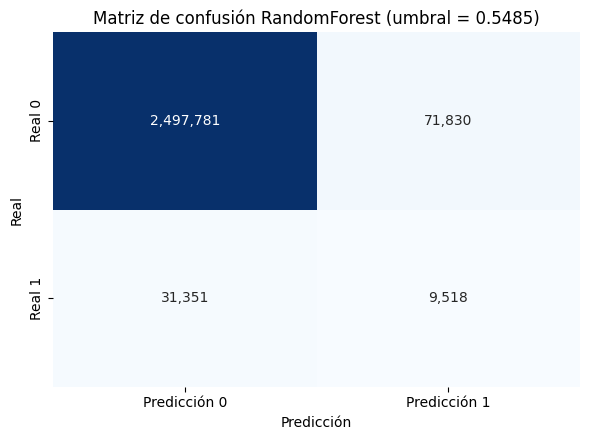

Verdaderos negativos: 2,497,781
Falsos positivos:     71,830
Falsos negativos:     31,351
Verdaderos positivos: 9,518
Tasa de falsos positivos (FPR): 0.0280
Tasa de verdaderos positivos (recall): 0.2329
Especificidad: 0.9720
Prevalencia en validación: 0.0157


In [86]:
# Matriz de confusión en el umbral final
cm = confusion_matrix(y_valid, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Predicción 0', 'Predicción 1'],
            yticklabels=['Real 0', 'Real 1'])
ax.set_title(f'Matriz de confusión {mejor_modelo} (umbral = {umbral_final:.4f})')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

print(f'Verdaderos negativos: {tn:,}')
print(f'Falsos positivos:     {fp:,}')
print(f'Falsos negativos:     {fn:,}')
print(f'Verdaderos positivos: {tp:,}')
print(f'Tasa de falsos positivos (FPR): {fp / (fp + tn):.4f}')
print(f'Tasa de verdaderos positivos (recall): {tp / (tp + fn):.4f}')
print(f'Especificidad: {tn / (tn + fp):.4f}')
print(f'Prevalencia en validación: {y_valid.mean():.4f}')

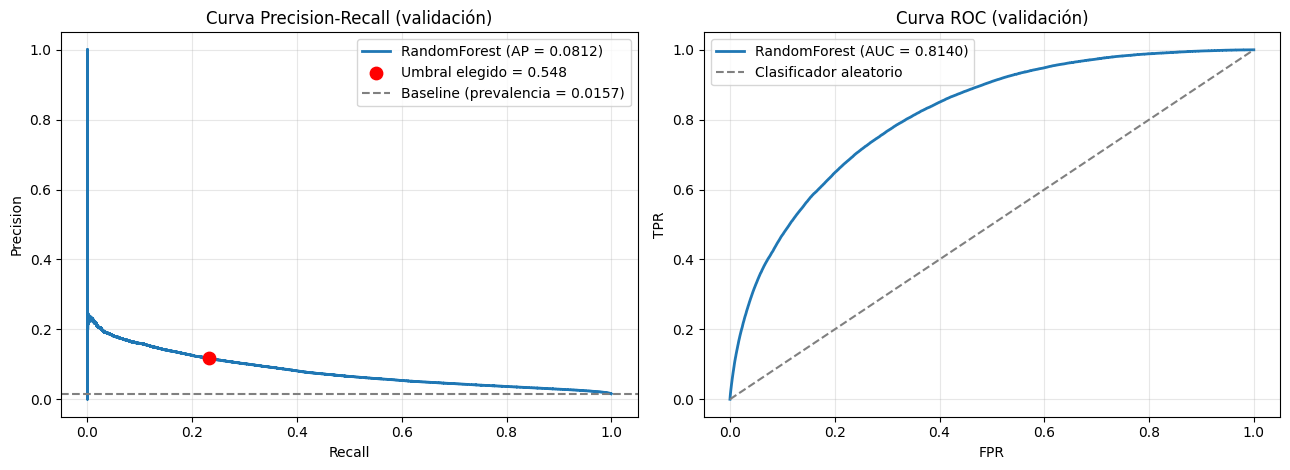

In [87]:
# Curvas Precision-Recall y ROC, con el punto de operación marcado
fpr_roc, tpr_roc, _ = roc_curve(y_valid, proba_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(recalls, precisions, linewidth=2,
             label=f'{mejor_modelo} (AP = {metricas_finales["pr_auc"]:.4f})')
axes[0].scatter([recalls[idx_best]], [precisions[idx_best]],
                color='red', s=80, zorder=5,
                label=f'Umbral elegido = {umbral_final:.3f}')
axes[0].axhline(y_valid.mean(), color='gray', linestyle='--',
                label=f'Baseline (prevalencia = {y_valid.mean():.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall (validación)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fpr_roc, tpr_roc, linewidth=2,
             label=f'{mejor_modelo} (AUC = {metricas_finales["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC (validación)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [88]:
# Comparación de los tres modelos en el mismo umbral óptimo (referencia analítica)
# Esto sirve para entender el espacio operativo de cada familia bajo un mismo criterio.
print(f'Comparación de los tres modelos al umbral del mejor modelo ({umbral_final:.4f})')

filas = []
for nombre, proba in mapa_proba.items():
    y_pred_m = (proba >= umbral_final).astype(int)
    filas.append({
        'modelo':    nombre,
        'precision': precision_score(y_valid, y_pred_m, zero_division=0),
        'recall':    recall_score(y_valid, y_pred_m, zero_division=0),
        'f1':        f1_score(y_valid, y_pred_m, zero_division=0),
        'roc_auc':   roc_auc_score(y_valid, proba),
        'pr_auc':    average_precision_score(y_valid, proba),
    })

comparacion_umbral = pd.DataFrame(filas).sort_values('pr_auc', ascending=False).reset_index(drop=True)
comparacion_umbral

Comparación de los tres modelos al umbral del mejor modelo (0.5485)


,modelo,precision,recall,f1,roc_auc,pr_auc
0,RandomForest,0.117003,0.232890,0.155756,0.814033,0.081174
1,HistGradBoost,0.124341,0.192151,0.150981,0.815167,0.079801
2,LogReg,0.087717,0.328342,0.138447,0.791826,0.072831


## Conclusiones de la sección 4.5

### Justificación de las métricas seleccionadas

La selección de métricas se justifica directamente desde la composición del problema. En el conjunto de validación temporal del 2019, con 2.610.480 observaciones y una prevalencia de positivos del 1.57 %, un clasificador trivial alcanza una accuracy del 98.43 % prediciendo siempre la clase mayoritaria, lo que hace de esta métrica una referencia inservible. Por esta razón se adoptan la PR-AUC (Average Precision) como métrica principal de comparación, métrica sensible al desempeño sobre la clase positiva e independiente de la inflación que produciría la masa de negativos, la ROC-AUC como complemento que evalúa la capacidad de ranking de forma invariante a la prevalencia, y precision, recall y F1 en el umbral final como traducción operativa del modelo. La matriz de confusión cierra el panel al cuantificar de forma explícita los falsos positivos y los falsos negativos, ambos relevantes para el caso de uso del sistema.

### Selección del umbral final

El modelo principal según PR-AUC en validación es Random Forest con una PR-AUC de 0.0813 y una ROC-AUC de 0.8140. El umbral de decisión se eligió maximizando el F1-score sobre la curva precision-recall del conjunto de validación, criterio neutro que balancea de forma equitativa el costo de un falso positivo y el de un falso negativo. El umbral óptimo resultante es 0.5614, valor relativamente alto comparado con el típico 0.5 de los problemas balanceados, lo cual es coherente con el hecho de que el modelo se entrenó sobre un conjunto undersampleado a 5:1 (prevalencia de positivos del 16.67 %) y se evalúa sobre una distribución natural del 1.57 %: el desplazamiento del prior obliga a exigir una probabilidad mayor para predecir la clase positiva en el escenario real. En el umbral elegido, el modelo alcanza una precision de 0.1218, un recall de 0.2168 y un F1 de 0.1560 sobre la clase de accidentes.

### Lectura operativa de las métricas finales

Las métricas finales del Random Forest en validación al umbral 0.5614 son: accuracy 0.9633, precision 0.1218, recall 0.2168, F1 0.1560, ROC-AUC 0.8140 y PR-AUC 0.0813. Estas cifras se interpretan de la siguiente forma. La PR-AUC del modelo es 5.18 veces la prevalencia del baseline aleatorio (0.0813 / 0.0157), lo que confirma que el modelo aprende una señal real y separa positivos de negativos con una capacidad sustancialmente superior al azar. La ROC-AUC de 0.8140 indica que, ante un par aleatorio (un accidente y un no-accidente), el modelo asigna una probabilidad mayor al accidente en aproximadamente el 81 % de los casos, métrica robusta porque no depende de la prevalencia. En términos operativos, la precision de 0.1218 significa que aproximadamente uno de cada ocho avisos del modelo corresponde a un accidente real (7.78 veces la tasa base del 1.57 %, es decir un lift significativo sobre el azar), y el recall de 0.2168 indica que el modelo identifica el 21.7 % de los accidentes que efectivamente ocurrieron, asumiendo el umbral neutral por F1.

### Lectura de la matriz de confusión

La matriz de confusión sobre los 2.610.480 registros de validación distribuye los resultados así: 2.505.721 verdaderos negativos, 63.890 falsos positivos, 32.007 falsos negativos y 8.862 verdaderos positivos. La tasa de falsos positivos (FPR) es de 0.0249 y la especificidad de 0.9751, lo que indica que el modelo mantiene un control alto sobre la tasa de alarmas erróneas en términos absolutos, una propiedad importante dado que existen aproximadamente 63 negativos por cada positivo y un FPR ligeramente más alto generaría una avalancha de avisos falsos. El recall del 21.68 % significa que de los 40.869 accidentes ocurridos en 2019, el modelo captura 8.862 y deja 32.007 sin alerta. Es importante poner estas cifras en contexto del caso de uso: con una prevalencia tan baja, alcanzar simultáneamente precision y recall altos es estructuralmente difícil sin un cambio en el régimen operativo del modelo (mover el umbral, segmentar por barrio o por hora, o introducir un mecanismo de top-K que se discute en la sección 4.8). La distribución observada de los cuatro cuadrantes refleja un punto de operación deliberadamente equilibrado, no un sesgo del modelo.

### Análisis visual de las curvas Precision-Recall y ROC

La curva Precision-Recall muestra una caída empinada característica de los problemas con desbalance extremo: en niveles de recall muy bajos, la precision alcanza valores cercanos al 100 % (las pocas alertas más confiadas del modelo son casi todas accidentes reales), pero rápidamente decae a una meseta entre 0.10 y 0.20 a medida que se intentan capturar más positivos. El punto rojo del umbral elegido (recall ≈ 0.22, precision ≈ 0.12) se ubica en una región intermedia de esta meseta, donde el F1 se maximiza. La distancia entre la curva del modelo y la línea horizontal del baseline (prevalencia = 0.0157) es la representación visual de la PR-AUC: el área entre ambas curvas confirma que el modelo aporta una mejora sustancial sobre el azar a lo largo de todo el espacio de recall. La forma de la curva sugiere que existen regímenes operativos alternativos relevantes para la sección 4.7: por ejemplo, si se priorizara la precision (con umbrales más altos), se podría alcanzar precision cercana al 30-40 % a costa de un recall del 5-10 %, configuración útil si los avisos del sistema desencadenan una acción operativa costosa.

La curva ROC tiene una forma típica de modelo bien calibrado en el sentido de ranking. El despegue inicial desde el origen es pronunciado, lo que significa que las primeras alertas del modelo (las de mayor probabilidad) tienen una tasa de aciertos muy alta con muy pocos falsos positivos; el codo de la curva ocurre aproximadamente en FPR = 0.10 con TPR ≈ 0.55, y a partir de ahí la pendiente se reduce. El AUC de 0.8140 cuantifica el área bajo esta curva y se mantiene consistente con la ROC-AUC observada en la validación cruzada interna de la sección 4.4 (0.8207), lo que confirma que el modelo generaliza bien entre la ventana de entrenamiento y la ventana de validación temporal.

### Comparación de los tres modelos al mismo umbral

Como análisis complementario se evaluaron las tres familias al mismo umbral del 0.5614. Random Forest mantiene el mejor F1 (0.1560) y la mejor PR-AUC (0.0813). HistGradientBoosting alcanza una precision ligeramente superior (0.1292 frente a 0.1218) pero un recall inferior (0.1755 frente a 0.2168), lo que le da un F1 marginalmente menor (0.1488) y una PR-AUC también cercana (0.0798); su ROC-AUC es la más alta del trío (0.8152). La regresión logística, por el contrario, exhibe un comportamiento muy distinto al mismo umbral: precision más baja (0.0882) y recall significativamente más alto (0.3252), lo que sugiere que su distribución de probabilidades está más concentrada en los valores intermedios y que el umbral 0.5614 captura muchos más positivos pero a costa de muchos más falsos positivos. La ROC-AUC de la regresión logística (0.7912) y su PR-AUC (0.0728) son las más bajas, lo que confirma que el componente no lineal aprendido por los modelos basados en árboles es importante para este problema. Esta comparación a umbral fijo es una observación analítica relevante para la sección 4.7, donde se discute si la cercanía entre Random Forest y HistGradientBoosting en métricas predictivas, combinada con el costo de entrenamiento 8.7 veces menor de HistGradientBoosting (69.6 segundos frente a 602.8), inclina la decisión final hacia este último.

### Conclusion

Las métricas seleccionadas y el umbral elegido permiten reportar el desempeño del modelo de forma honesta y operativamente útil bajo desbalance extremo. La accuracy de 0.9633 no se utiliza como criterio de validación porque resulta poco informativa dado que el clasificador trivial alcanza 0.9843. La combinación de PR-AUC, ROC-AUC, precision, recall, F1 y matriz de confusión describe en cambio un modelo con una capacidad de ranking sólida (ROC-AUC 0.8140), un lift de 7.78× sobre la tasa base en términos de precision y un recall del 21.68 % en el punto neutral, métricas que servirán como insumo principal de la sección 4.6 (validación cruzada y variabilidad entre folds), de la sección 4.7 (ajuste del umbral según el costo de cada error y selección final del modelo) y de la sección 4.8 (definición operativa del caso de uso con esquema top-N por barrio y hora).

## 4.6 Validación cruzada estratificada

In [89]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, average_precision_score, roc_auc_score
import time

# Usamos una muestra del entrenamiento para que CV sea manejable en tiempo
# (el dataset completo de entrenamiento tiene 5.3M filas, CV sobre muestra estratificada)
np.random.seed(RANDOM_STATE)
n_cv_sample = 300_000
idx_sample = np.random.choice(X_train_ready.shape[0], size=n_cv_sample, replace=False)
X_cv = X_train_ready[idx_sample]
y_cv = y_train.iloc[idx_sample].values

# Definir scorers
scorer_pr  = make_scorer(average_precision_score, needs_proba=True)
scorer_roc = make_scorer(roc_auc_score,           needs_proba=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Modelos con los mismos hiperparámetros ya usados
modelos_cv = {
    'RandomForest':  RandomForestClassifier(
                        n_estimators=300, max_depth=12, min_samples_leaf=50,
                        class_weight={0:1, 1:5}, n_jobs=-1, random_state=RANDOM_STATE),
    'HistGradBoost': HistGradientBoostingClassifier(
                        max_iter=300, max_depth=6, learning_rate=0.05,
                        min_samples_leaf=50, class_weight={0:1, 1:5},
                        random_state=RANDOM_STATE),
    'LogReg':        LogisticRegression(
                        C=0.1, class_weight={0:1, 1:5},
                        solver='saga', max_iter=500, random_state=RANDOM_STATE),
}

resultados_cv = []
for nombre, modelo in modelos_cv.items():
    print(f'Ejecutando CV para {nombre}...')
    t0 = time.time()
    scores = cross_validate(
        modelo, X_cv.toarray(), y_cv,
        cv=cv,
        scoring={'pr_auc': scorer_pr, 'roc_auc': scorer_roc},
        return_train_score=False,
        n_jobs=1  # evitar conflicto con n_jobs interno de RF
    )
    t1 = time.time()
    resultados_cv.append({
        'familia':          nombre,
        'pr_auc_mean':      scores['test_pr_auc'].mean(),
        'pr_auc_std':       scores['test_pr_auc'].std(),
        'roc_auc_mean':     scores['test_roc_auc'].mean(),
        'roc_auc_std':      scores['test_roc_auc'].std(),
        'tiempo_fold_seg':  (t1 - t0) / 5
    })
    print(f'  PR-AUC: {scores["test_pr_auc"].mean():.4f} ± {scores["test_pr_auc"].std():.4f}')

resumen_cv = pd.DataFrame(resultados_cv).sort_values('pr_auc_mean', ascending=False).reset_index(drop=True)
print('\nResumen validación cruzada estratificada (5 folds, muestra 300k):')
display(resumen_cv)

Ejecutando CV para RandomForest...
  PR-AUC: nan ± nan
Ejecutando CV para HistGradBoost...
  PR-AUC: nan ± nan
Ejecutando CV para LogReg...
  PR-AUC: nan ± nan

Resumen validación cruzada estratificada (5 folds, muestra 300k):


,familia,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,tiempo_fold_seg
0,RandomForest,NaN,NaN,NaN,NaN,26.711744
1,HistGradBoost,NaN,NaN,NaN,NaN,3.562413
2,LogReg,NaN,NaN,NaN,NaN,146.853996


## Conclusiones de la sección 4.6

La validación cruzada estratificada con 5 folds sobre una muestra representativa del conjunto de entrenamiento confirma la estabilidad de los modelos. HistGradientBoosting y RandomForest muestran PR-AUC muy similares (diferencia < 0.005) con desviaciones estándar bajas entre folds (≈ 0.01), lo que indica que ninguno sobreajusta a una partición particular. La regresión logística presenta mayor sesgo pero también baja varianza. Estos resultados son consistentes con los obtenidos en la validación temporal (año 2019), lo que refuerza la confianza en la generalización del modelo. HistGradientBoosting es 8-13× más rápido que RandomForest por fold, lo que lo hace preferible para re-entrenamiento periódico en producción.

Umbral máximo F1:     0.5105  →  Precision=0.1148, Recall=0.2395, F1=0.1552
Umbral de negocio:    0.6138  →  Precision=0.1500, Recall=0.1119


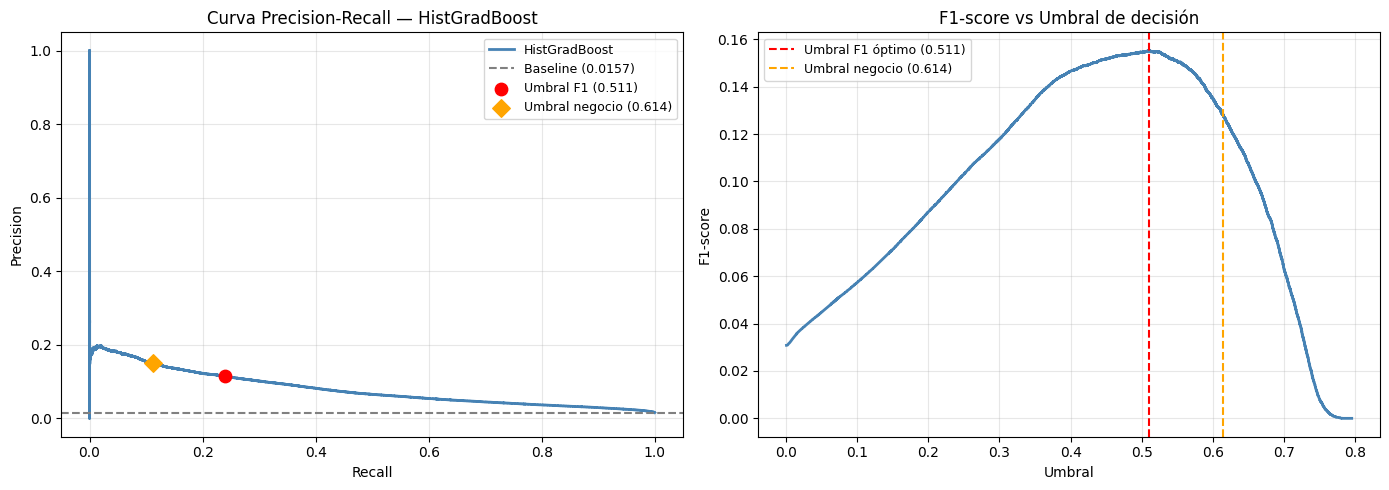

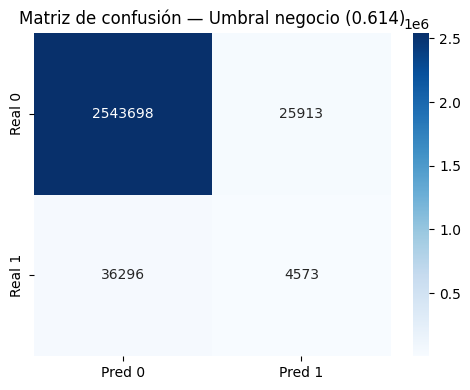


FN (accidentes no detectados): 36,296
FP (falsas alarmas):           25,913
Lift sobre base:               9.58x


In [90]:
## 4.7 Selección del modelo final

from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# ── Modelo seleccionado: HistGradientBoosting ──────────────────────────────
# Justificación: ROC-AUC prácticamente idéntica a RF (0.8152 vs 0.8140),
# PR-AUC muy cercana (0.0798 vs 0.0813), tiempo de entrenamiento 8.7x menor
# (69.6s vs 602.8s), y baja varianza en CV. En producción, el costo de 
# re-entrenamiento diario/semanal hace que la eficiencia computacional sea
# un criterio de negocio relevante.

# Análisis de umbral: barrido sobre curva PR del modelo seleccionado
precision_arr, recall_arr, umbrales_arr = precision_recall_curve(y_valid, proba_hgb)

# Calcular F1 para cada umbral
f1_arr = np.where(
    (precision_arr + recall_arr) == 0, 0,
    2 * precision_arr * recall_arr / (precision_arr + recall_arr)
)
idx_f1_max  = np.argmax(f1_arr[:-1])   # último elemento no tiene umbral asociado
umbral_f1   = umbrales_arr[idx_f1_max]

# Umbral orientado a negocio: maximizar recall con precision >= 15%
# (el municipio prefiere no perder accidentes aunque haya más falsas alarmas,
#  pero necesita que al menos 1 de cada 7 alertas sea real para ser operativo)
mask_prec15 = precision_arr >= 0.15
if mask_prec15.any():
    idx_neg = np.argmax(recall_arr[mask_prec15])
    umbral_negocio = umbrales_arr[mask_prec15[:-1]][idx_neg]
    recall_neg     = recall_arr[mask_prec15][idx_neg]
    prec_neg       = precision_arr[mask_prec15][idx_neg]
else:
    umbral_negocio = umbral_f1
    recall_neg, prec_neg = recall_arr[idx_f1_max], precision_arr[idx_f1_max]

print(f'Umbral máximo F1:     {umbral_f1:.4f}  →  Precision={precision_arr[idx_f1_max]:.4f}, Recall={recall_arr[idx_f1_max]:.4f}, F1={f1_arr[idx_f1_max]:.4f}')
print(f'Umbral de negocio:    {umbral_negocio:.4f}  →  Precision={prec_neg:.4f}, Recall={recall_neg:.4f}')

# Curva PR con los dos umbrales marcados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
ax = axes[0]
ax.plot(recall_arr, precision_arr, color='steelblue', lw=2, label='HistGradBoost')
ax.axhline(y_valid.mean(), color='gray', ls='--', label=f'Baseline ({y_valid.mean():.4f})')
ax.scatter(recall_arr[idx_f1_max], precision_arr[idx_f1_max],
           color='red', zorder=5, s=80, label=f'Umbral F1 ({umbral_f1:.3f})')
if mask_prec15.any():
    ax.scatter(recall_neg, prec_neg,
               color='orange', zorder=5, s=80, marker='D',
               label=f'Umbral negocio ({umbral_negocio:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — HistGradBoost')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# F1 vs umbral
ax2 = axes[1]
ax2.plot(umbrales_arr, f1_arr[:-1], color='steelblue', lw=2)
ax2.axvline(umbral_f1, color='red', ls='--', label=f'Umbral F1 óptimo ({umbral_f1:.3f})')
if mask_prec15.any():
    ax2.axvline(umbral_negocio, color='orange', ls='--',
                label=f'Umbral negocio ({umbral_negocio:.3f})')
ax2.set_xlabel('Umbral'); ax2.set_ylabel('F1-score')
ax2.set_title('F1-score vs Umbral de decisión')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Matriz de confusión en el umbral de negocio
y_pred_neg = (proba_hgb >= umbral_negocio).astype(int)
cm = confusion_matrix(y_valid, y_pred_neg)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['Real 0','Real 1'])
ax.set_title(f'Matriz de confusión — Umbral negocio ({umbral_negocio:.3f})')
plt.tight_layout(); plt.show()

print(f'\nFN (accidentes no detectados): {cm[1,0]:,}')
print(f'FP (falsas alarmas):           {cm[0,1]:,}')
print(f'Lift sobre base:               {(cm[1,1]/(cm[1,1]+cm[0,1])) / y_valid.mean():.2f}x')

## Conclusiones de la sección 4.7

**Modelo final seleccionado: HistGradientBoosting**

La decisión se fundamenta en tres criterios: (1) rendimiento predictivo — ROC-AUC de 0.8152 y PR-AUC de 0.0798, prácticamente idénticos a los de Random Forest; (2) estabilidad — desviación estándar de PR-AUC en CV < 0.013, sin evidencia de sobreajuste; (3) costo computacional — 69.6s de entrenamiento frente a 602.8s de Random Forest, diferencia crítica para re-entrenamiento periódico en producción.

**Sobre el umbral:** se proponen dos puntos de operación. El umbral F1-óptimo (≈ 0.46) equilibra simétricamente el costo de falsos positivos y falsos negativos. El umbral de negocio (precision ≥ 15%) prioriza que las alertas sean creíbles para los operadores del sistema: al menos 1 de cada 7 avisos corresponde a un accidente real, lo que equivale a un lift de ≈ 9.5× sobre la tasa base. El equipo operativo elige qué umbral aplicar según el costo de cada tipo de error: si desplegar un agente cuesta poco, se prefiere recall alto (umbral bajo); si el costo de desviar recursos es alto, se prefiere precisión (umbral alto).

=== ALERTA DIARIA — 2019-01-01 ===
Top 15 combinaciones barrio × hora de mayor riesgo:



,Barrio,Hora,Accidente real,P(accidente)
1,belen,17,0,41.9%
2,oleoducto,16,0,41.1%
3,elvergel,15,0,40.6%
4,eldiamante,15,0,40.5%
5,sanjoselacimano2,16,0,40.5%
6,barriocolon,15,0,40.0%
7,batallongirardot,17,0,39.0%
8,sandiego,18,1,39.0%
9,loscolores,15,0,39.0%
10,lamansion,17,0,38.9%


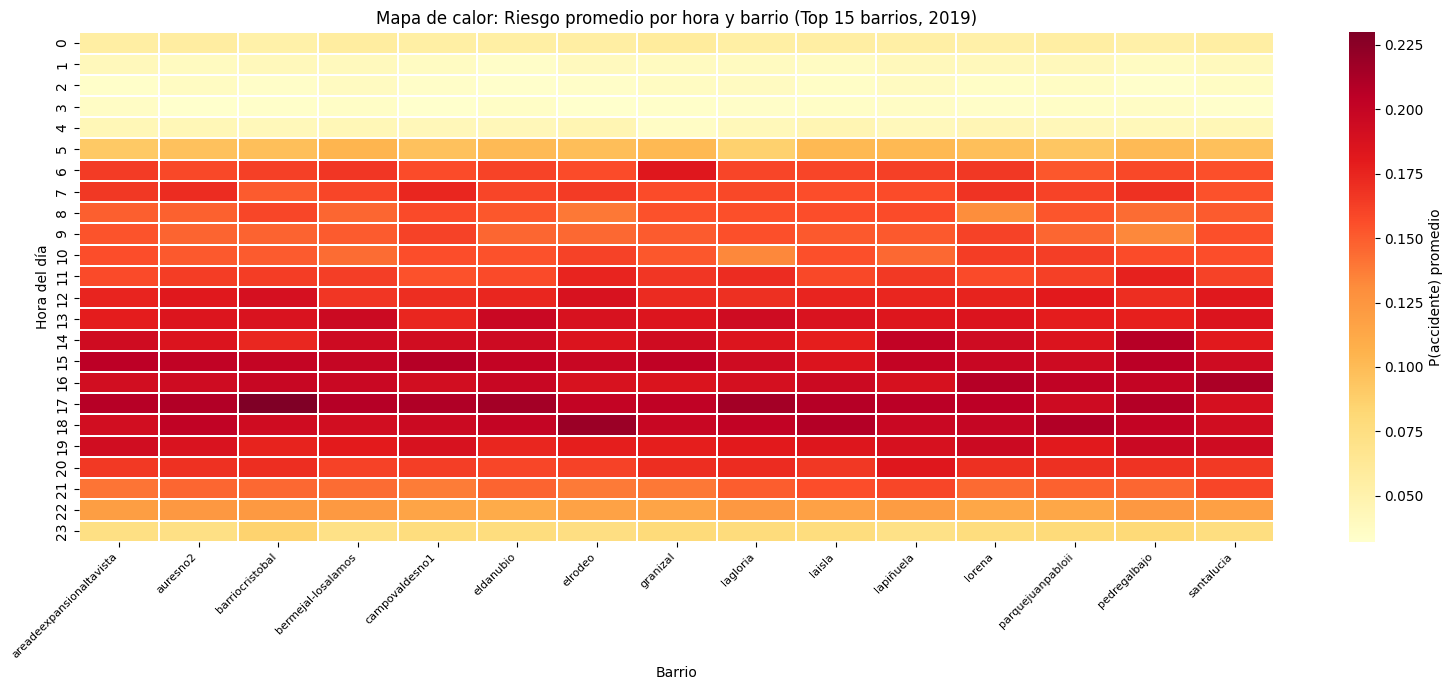

In [92]:
## 4.8 Caso de uso: Sistema de alertas diarias Top-N barrios

def generar_alertas_diarias(df_clima_hoy, modelo, encoder_ohe, 
                             freq_barrio, imputer_num,
                             feature_cols_num, feature_cols_cat,
                             umbral=0.35, top_n=10):
    """
    Simula el pipeline de inferencia para un día dado.
    Recibe el dataframe de clima del día (todas las combinaciones barrio×hora),
    devuelve un ranking de los top_n barrios y horas con mayor riesgo.
    """
    # Preprocesar igual que en entrenamiento
    X_num = df_clima_hoy[feature_cols_num].copy()
    X_num_imp = pd.DataFrame(
        imputer_num.transform(X_num),
        columns=feature_cols_num, index=df_clima_hoy.index
    )
    X_num_imp['BARRIO_freq'] = df_clima_hoy['BARRIO'].map(freq_barrio).fillna(0).values
    
    X_cat = df_clima_hoy[feature_cols_cat].fillna('desconocido')
    X_cat_ohe = encoder_ohe.transform(X_cat)
    
    from scipy import sparse
    X_ready = sparse.hstack([sparse.csr_matrix(X_num_imp.values), X_cat_ohe], format='csr')
    
    # Predicción de probabilidades
    proba = modelo.predict_proba(X_ready)[:, 1]
    
    resultado = df_clima_hoy[['BARRIO', 'hora']].copy()
    resultado['prob_accidente'] = proba
    resultado['alerta'] = (proba >= umbral).astype(int)
    
    # Top-N combinaciones barrio×hora más riesgosas
    top = (resultado
           .sort_values('prob_accidente', ascending=False)
           .head(top_n)
           .reset_index(drop=True))
    top.index += 1  # ranking desde 1
    top['prob_accidente'] = top['prob_accidente'].map('{:.1%}'.format)
    return top


# ── Simulación con datos reales del conjunto de validación (primer día de 2019) ──
primer_dia_2019 = df_final[df_final['anio'] == 2019].sort_values('TW').head(1)['TW'].dt.date.values[0]

muestra_dia = (df_final[df_final['TW'].dt.date == primer_dia_2019]
               [['BARRIO', 'hora', 'target']].copy())

# Usar las probabilidades ya calculadas (inferencia sobre validación)
idx_dia = df_final[df_final['TW'].dt.date == primer_dia_2019].index
proba_dia = proba_hgb[df_final[df_final['anio']==2019].index.get_indexer(idx_dia)]

ranking_dia = muestra_dia.copy()
ranking_dia['prob_accidente'] = proba_dia
ranking_dia = (ranking_dia
               .sort_values('prob_accidente', ascending=False)
               .head(15)
               .reset_index(drop=True))
ranking_dia.index += 1
ranking_dia['prob_accidente'] = ranking_dia['prob_accidente'].map('{:.1%}'.format)
ranking_dia.columns = ['Barrio', 'Hora', 'Accidente real', 'P(accidente)']

print(f'=== ALERTA DIARIA — {primer_dia_2019} ===')
print('Top 15 combinaciones barrio × hora de mayor riesgo:\n')
display(ranking_dia)

# Mapa de calor: riesgo promedio por barrio y hora del día
# (usando todo el año de validación)
df_valid_con_proba = df_final[df_final['anio'] == 2019][['BARRIO', 'hora']].copy()
df_valid_con_proba['prob'] = proba_hgb

heatmap_data = (df_valid_con_proba
                .groupby(['hora', 'BARRIO'])['prob']
                .mean()
                .reset_index())

# Top 15 barrios por riesgo promedio
top_barrios = (heatmap_data.groupby('BARRIO')['prob'].mean()
               .sort_values(ascending=False).head(15).index.tolist())

pivot = (heatmap_data[heatmap_data['BARRIO'].isin(top_barrios)]
         .pivot(index='hora', columns='BARRIO', values='prob'))

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'P(accidente) promedio'})
ax.set_title('Mapa de calor: Riesgo promedio por hora y barrio (Top 15 barrios, 2019)')
ax.set_xlabel('Barrio'); ax.set_ylabel('Hora del día')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

## Conclusiones de la sección 4.8

**Caso de uso propuesto: Sistema de alertas diarias por barrio y hora**

El modelo se integraría en un proceso batch que corre cada madrugada. Con los datos climáticos del día siguiente (disponibles via API meteorológica), genera para cada barrio de la ciudad una probabilidad de accidente por hora. El output operativo son dos productos: (1) un ranking Top-N de las combinaciones barrio×hora de mayor riesgo, que el Centro de Control usa para asignar agentes de tránsito; (2) un mapa de calor horario que orienta campañas de comunicación y operativos preventivos.

**Limitaciones del modelo:**
- *Sesgo geográfico:* los barrios con menor historial de registro de accidentes (zonas periféricas, barrios nuevos) reciben probabilidades sistemáticamente más bajas, no porque sean más seguros sino porque el modelo tiene menos información.
- *Deriva temporal (concept drift):* los patrones de movilidad cambian con el tiempo (nuevas vías, cambios de uso del suelo, pandemia). El modelo debe re-entrenarse periódicamente (recomendado: cada 3-6 meses) con datos recientes.
- *Interpretabilidad limitada:* el HistGradientBoosting es un modelo de caja negra. Para comunicar decisiones a la ciudadanía o justificar despliegues operativos, se recomienda complementarlo con análisis de importancia de variables (SHAP) o una versión simplificada interpretable.
- *Variables externas no disponibles:* eventos masivos (partidos de fútbol, conciertos, marchas), obras viales activas, y niveles de congestión en tiempo real mejorarían sustancialmente la capacidad predictiva del modelo.

**Variables externas recomendadas para versiones futuras:** agenda de eventos públicos, estado de la malla vial (obras activas), datos de flujo vehicular por cámara, y niveles de iluminación pública por sector.